# INF 791 - Tópicos Especiais II – Redes Complexas
## Trabalho Prático - Intermediário

### Pedro Henrique Silva Oliveira - EF02677

**PS: As imagens desse trabalho estão sendo renderizadas localmente pois ao trabalhar com elas em meu computador ele estava travando. Portanto, para visualizar as imagens do presente é necessário estar executando em um ambiente virtual local (No próprio computador) ou clicar na imagem quando a mesma for pertinente para análise. Desde já agradeço pela compreensão!**   

# 1. Coleta de Dados

## (a) Escolha do Sistema e Construção do Coletor do Grafo

### Base de dados escolhida  
A base de dados escolhida para esta análise é a Social circles: Facebook (Facebook Ego Networks), obtida através da coleção pública SNAP (Stanford Large Network Dataset Collection) e coletada originalmente em 2012 pelos pesquisadores Jure Leskovec e Julian McAuley. 

* Fonte dos dados: http://snap.stanford.edu/data/ego-Facebook.html

É importante destacar que não estamos consultando a base total do Facebook em tempo real, que é privada por segredo comercial e segurança. Em vez disso, estamos utilizando um dataset histórico e estático composto onde a principal peculiaridade do grafo é a fusão de estruturas egocêntricas independentes (ego-network). Uma ego-network é uma rede formada por um usuário focal (o "Ego"), todos os seus contatos diretos (amigos), e todas as conexões existentes entre esses próprios contatos. Esses dados foram obtidos de voluntários reais que aceitaram mapear seus círculos de amizades de forma totalmente anonimizada para fins acadêmicos.

Em vez de ser uma amostragem aleatória e uniforme da rede global do Facebook, o que poderia gerar uma topologia artificialmente desconexa ou esparsa, este grafo é a sobreposição de 10 ego-networks completas. Isso significa que ele preserva as propriedades locais de conectividade humana, como as bolhas e comunidades, mas também exibe as conexões cruzadas entre diferentes círculos, onde alguns usuários atuam como pontes estruturais de contato.

A proposta central em relação a este grafo é comprovar empiricamente propriedades clássicas e leis universais de redes sociais reais que estudamos em sala de aula. Utilizando este dataset do Facebook como nosso laboratório empírico de testes, pretendemos avaliar como essas propriedades estruturais e teóricas se manifestam de forma prática em redes online. Partindo da rede formada por esse dataset, serão avaliadas as seguintes métricas de redes complexas:
* **Grau Médio e Distribuição de Grau**: Esta métrica quantifica a popularidade individual de cada nó, determinando exatamente a quantidade de amigos de um usuário. Será utilizada para expor a desigualdade de popularidade na rede. O objetivo com essa métrica é verificar se o grafo apresenta um comportamento Livre de Escala (*Scale-Free*), caracterizado por uma minoria de usuários com um número gigantesco de ligações.
* **Coeficiente de Clusterização**: Através do coeficiente de clusterização vamos medir matematicamente a probabilidade de que dois amigos de um determinado usuário também sejam amigos entre si. Utilizaremos esse cálculo na análise para comprovar o princípio do "Fechamento Triádico", atestando se a rede do Facebook possui uma tendência à formação de comunidades isoladas, panelinhas e bolhas sociais densas.
* **Distância Média**: A distância média será calculada para encontrar o número mínimo de conexões necessárias para que uma informação vá de um usuário qualquer até outro dentro do grafo. Essa métrica servirá para comprovar de forma empírica a teoria dos "Seis Graus de Separação" e demonstrar o fenômeno do Mundo Pequeno (*Small-World*).
* **Sobreposição de Vizinhança (Overlap)**: O *overlap* medirá a quantidade percentual de amigos que duas pessoas conectadas possuem em comum. Nas análises, essa métrica será o pilar para diferenciar e validar a teoria sociológica dos laços. Conseguiremos identificar quais arestas são "Laços Fortes" e quais são "Laços Fracos".
* **Componentes Conexos**: Por fim, o cálculo de componentes conexos identificará se existem ilhas de usuários completamente isoladas do resto do grafo e qual o tamanho exato de cada um desses blocos. A análise partirá dessa contagem para confirmar a tendência das redes de conectarem a vasta maioria de seus participantes em um único "Componente Gigante" contínuo.

### O coletor de dados  
Para baixar e processar os dados de forma automatizada, o código realiza as seguintes operações:

1. **Verificação de Arquivo (`os.path.exists`)**: Verifica se o arquivo final descompactado (`facebook_combinado.txt`) já existe localmente para evitar downloads repetidos.
2. **Download dos Dados (`requests.get`)**: Caso não exista, faz o download do dataset compactado (`facebook_combinado.txt.gz`) a partir do repositório público do SNAP.
3. **Extração e Descompactação (`gzip.open` e `shutil.copyfileobj`)**: Abre o arquivo compactado e extrai o seu conteúdo para um arquivo de texto plano.
4. **Construção do Grafo (`nx.read_edgelist`)**: Lê a lista de conexões do arquivo de texto e modela a rede como um grafo não-direcionado (`nx.Graph()`) na variável `grafo`, definindo os nós como números inteiros (`nodetype=int`) para otimizar o desempenho.
5. **Exportação para o Gephi (`nx.write_gexf`)**: Exporta a estrutura do grafo construído em memória para o formato GEXF (`facebook_combinado.gexf`), permitindo que a rede seja importada no software externo Gephi para a geração de visualizações em alta resolução e análise espacial avançada.


In [2]:
import networkx as nx
import requests
import gzip
import shutil
import os

# Configurações de URL e arquivos locais
url_dados = "https://snap.stanford.edu/data/facebook_combined.txt.gz"
arquivo_gz = "facebook_combinado.txt.gz"
arquivo_txt = "facebook_combinado.txt"

# 1. Coleta / Download dos dados brutos via HTTP
if not os.path.exists(arquivo_txt):
    print("Iniciando coleta...")
    resposta = requests.get(url_dados, stream=True)
    if resposta.status_code == 200:
        with open(arquivo_gz, 'wb') as arq_saida:
            shutil.copyfileobj(resposta.raw, arq_saida)
        print("Download dos dados concluído!")
        
        # 2. Descompactação
        print("Extraindo o dataset...")
        with gzip.open(arquivo_gz, 'rb') as arq_entrada:
            with open(arquivo_txt, 'wb') as arq_saida:
                shutil.copyfileobj(arq_entrada, arq_saida)
        print("Extração concluída!")
    else:
        print(f"Falha ao baixar o arquivo. Código de status: {resposta.status_code}")
else:
    print("O dataset já foi coletado e está presente no diretório local.")

# 3. Construção do grafo
print("\nMontando a rede complexa na memória...")
grafo = nx.read_edgelist(arquivo_txt, create_using=nx.Graph(), nodetype=int)
print("Grafo construído com sucesso!")

# 4. Exportação para visualização no Gephi
arquivo_gexf = "facebook_combinado.gexf"
nx.write_gexf(grafo, arquivo_gexf)
print(f"Arquivo '{arquivo_gexf}' exportado com sucesso para visualização no Gephi!")


O dataset já foi coletado e está presente no diretório local.

Montando a rede complexa na memória...
Grafo construído com sucesso!
Arquivo 'facebook_combinado.gexf' exportado com sucesso para visualização no Gephi!


## (b) Identificação e Discussão do Grafo Estudado

### Grafo estudado

=== CARACTERÍSTICAS ESTRUTURAIS DO GRAFO ===
Total de Nós (Usuários): 4039
Total de Arestas (Conexões): 88234
Densidade do Grafo: 0.010820 (1.0820%)
--------------------------------------------------
=== PROPRIEDADES DO MAIOR HUB ===
ID do Nó Analisado (Ego): 107
Número de Vizinhos (Alters/Grau): 1045
--------------------------------------------------
Extraindo a Ego-Network do nó 107...
Calculando o layout espacial da Ego-Network...
Renderizando conexões da Ego-Network...
Renderizando atores (Ego e Alters)...


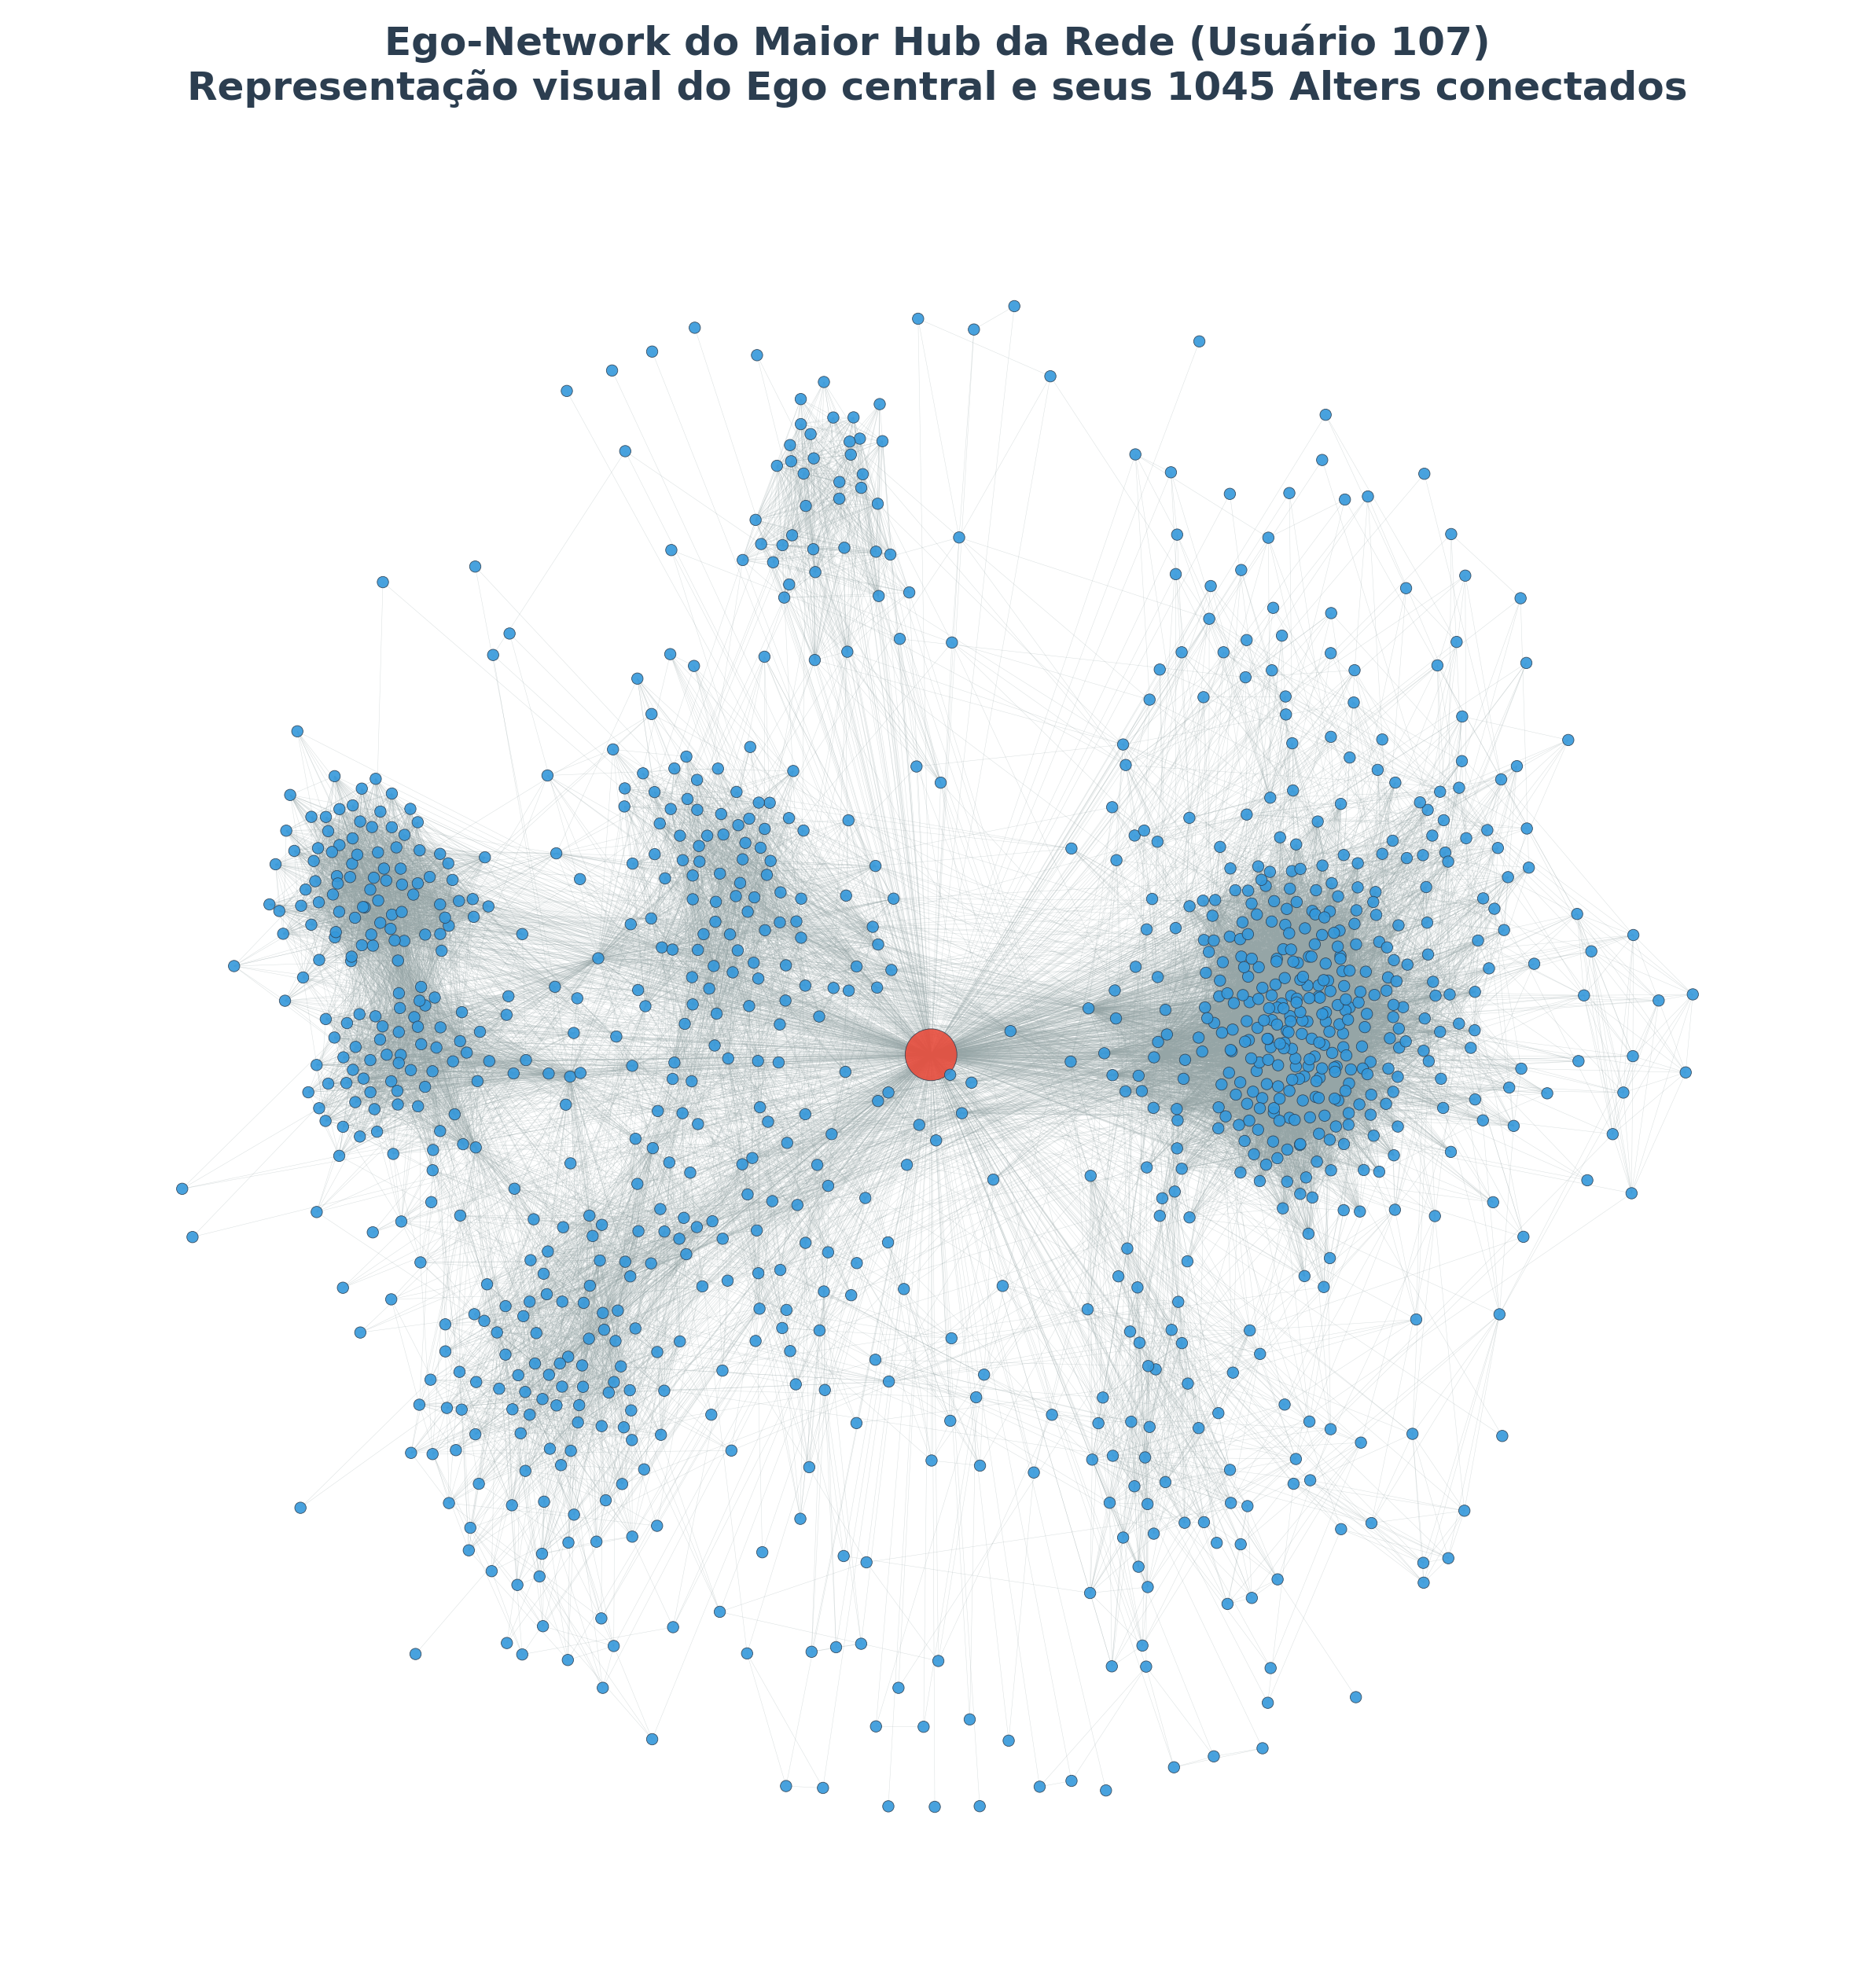

In [3]:
# Código para gerar a visualização da Ego-Network do maior Hub (Nó 107)
import matplotlib.pyplot as plt
import networkx as nx

# 1. Características estruturais globais da rede
print("=== CARACTERÍSTICAS ESTRUTURAIS DO GRAFO ===")
num_nos = grafo.number_of_nodes()
num_arestas = grafo.number_of_edges()
densidade = nx.density(grafo)
print(f"Total de Nós (Usuários): {num_nos}")
print(f"Total de Arestas (Conexões): {num_arestas}")
print(f"Densidade do Grafo: {densidade:.6f} ({densidade * 100:.4f}%)")
print("-" * 50)

# 2. Identificar o Hub Representativo (Nó 107)
no_hub = max(grafo.nodes(), key=grafo.degree)
grau_hub = grafo.degree(no_hub)
print("=== PROPRIEDADES DO MAIOR HUB ===")
print(f"ID do Nó Analisado (Ego): {no_hub}")
print(f"Número de Vizinhos (Alters/Grau): {grau_hub}")
print("-" * 50)

# 3. Extrair a Ego-Network do Nó 107
print("Extraindo a Ego-Network do nó 107...")
subgrafo_ego = nx.ego_graph(grafo, no_hub)

# 4. Configurar estilo visual premium para o plot
plt.figure(figsize=(10, 10), dpi=300)
plt.rcParams['font.family'] = 'sans-serif'

# 4.1 Posições espaciais do subgrafo ego (Layout de Força Spring/Fruchterman-Reingold)
print("Calculando o layout espacial da Ego-Network...")
posicao = nx.spring_layout(subgrafo_ego, k=0.08, seed=42)

# 4.2 Definir cores e tamanhos diferenciados para o Ego (nó 107) e os Alters (vizinhos)
cores_nos = []
tamanhos_nos = []
for no in subgrafo_ego.nodes():
    if no == no_hub:
        cores_nos.append('#e74c3c')       # Ego: Vermelho vibrante
        tamanhos_nos.append(250)          # Ego: Tamanho de destaque
    else:
        cores_nos.append('#3498db')       # Alters: Azul suave
        tamanhos_nos.append(12)           # Alters: Pequenos

# 4.3. Desenhar arestas ultra-finas e semi-transparentes para as conexões mútuas
print("Renderizando conexões da Ego-Network...")
nx.draw_networkx_edges(subgrafo_ego, posicao, width=0.12, alpha=0.35, edge_color='#95a5a6')

# 4.4. Desenhar os nós
print("Renderizando atores (Ego e Alters)...")
nx.draw_networkx_nodes(
    subgrafo_ego, posicao,
    node_size=tamanhos_nos,
    node_color=cores_nos,
    alpha=0.9,
    linewidths=0.2,
    edgecolors='#2c3e50'
)

# 4.5. Finalizar estética da visualização
plt.title(f'Ego-Network do Maior Hub da Rede (Usuário {no_hub})\n' 
          f'Representação visual do Ego central e seus {subgrafo_ego.number_of_nodes() - 1} Alters conectados',
          fontsize=12, fontweight='bold', pad=15, color='#2c3e50')
plt.axis('off')

# 4.6. Salvar e exibir a imagem no notebook
plt.savefig("visualizacao_grafo_no_107.png", bbox_inches='tight', dpi=300)
plt.show()


O grafo selecionado para este estudo consiste na união de 10 redes egocêntricas (ou *ego-networks*) extraídas de perfis reais do Facebook, contendo 4.039 usuários (nós) e 88.234 relações de amizade mútuas (arestas). Trata-se de uma rede social não-direcionada e não-ponderada, ideal para investigar padrões clássicos de agrupamento social, homofilia e propriedades de conectividade humana.

A densidade é de aproximadamente 1,0820\% (0,010820). Isso revela que a rede é extremamente esparsa, já que pouco mais de 1\% de todas as amizades teoricamente possíveis entre os 4.039 usuários realmente existem. O nó 107, o Ego com mais conectividade da nossa rede, possui 1.045 vizinhos. O que representa aproximadamente 25,87% de todos os usuários da rede. Esse comportamento é típico de redes reais que contêm 'hubs' altamente conectados. Portanto, apesar de ser globalmente esparsa, é esperado que essa rede seja densa de forma local (panelinhas), concentrando suas conexões nos nós Ego.

### Visualização do grafo do nó 107 

<div align="center">
  <img src="visualizacao_grafo_no_107.png" width="70%" alt="Visualização da Ego-Network do Hub 107" />
</div>

### Limitações do grafo
Como os dados foram consolidados a partir de um conjunto restrito de 10 indivíduos focais (os egos), a amostra possui limitações inerentes de representatividade:
* **Viés de seleção**: A topologia reflete quase que inteiramente os círculos de amizade específicos das 10 pessoas escolhidas para a coleta inicial, não sendo uma amostra aleatória uniforme de toda a plataforma.
* **Efeito de borda**: Conexões que os membros da rede possuem com usuários externos aos 10 círculos egocêntricos não foram coletadas. Isso tende a distorcer certas métricas de centralidade e distâncias globais na comparação com a rede real completa.
* **Natureza estática**: A rede representa uma fotografia instantânea e anonimizada capturada no ano de 2012, de modo que não captura a evolução temporal e novas interações adicionadas.

### Estimativa da fração da rede coletada
Na época de compilação aproximada deste dataset pelo projeto *SNAP*, o Facebook contava com cerca de 1 bilhão de usuários ativos mensais (1.000.000.000 de nós). Como o subgrafo em análise possui 4.039 nós, a fração que ele representa em relação ao grafo total é estimada em:
$$\frac{4.039}{1.000.000.000} \approx 4 \times 10^{-6} = 0,0004\%$$

Esse grafo corresponde a menos de quatro milionésimos da rede global da plataforma na época. Embora a fração global seja extremamente pequena.

# 2. Análise de uma Rede Complexa

## (a) Explicação da Rede Analisada

A rede social é modelada formalmente como um grafo simples, não-direcionado e não-ponderado $G = (V, E)$. Nesse modelo matemático, o conjunto de vértices $V$ (nós) é composto por usuários do Facebook, enquanto o conjunto de arestas $E$ (links) é definido pelas relações de amizade mútua estabelecidas entre eles, de modo que uma ligação $(u, v) \in E$ existe apenas se ambos os indivíduos concordaram com a amizade.

A natureza simétrica desse relacionamento caracteriza a rede como inerentemente não-direcionada. Além disso, o grafo é não-ponderado por não dispormos de dados sobre a frequência de interação ou intensidade das conexões, sendo atribuído um peso unitário $w(u,v) = 1$ para todas as arestas existentes. Trata-se de um grafo simples, dada a ausência de *loops* ou arestas paralelas entre um mesmo par de atores.

Do ponto de vista computacional, a rede é representada como uma lista de adjacências. Com um total de $4.039$ nós e $88.234$ arestas, a densidade global do grafo é de aproximadamente apenas $1,08\%$. Essa expressiva esparsidade justifica o uso da lista de adjacências em detrimento da matriz de adjacências, uma vez que a matriz seria composta majoritariamente por zeros, desperdiçando memória. 

Topologicamente, a rede reflete a fusão de 10 *ego-networks* completas. Essa estratégia de formação resulta em um grafo com uma arquitetura híbrida singular, caracterizada por uma altíssima densidade local e forte coesão comunitária ao redor de nós centrais (os "Egos"), mantendo ao mesmo tempo uma conectividade global viabilizada por pontes.


## (b) Distribuição e Grau Médio da Rede

### Cálculos Estatísticos

Para o cálculo do grau médio ($\langle k \rangle$), utilizamos a fórmula baseada na soma dos graus individuais ($k_i$) de todos os nós dividida pelo número total de vértices ($N = |V|$):

$$\langle k \rangle = \frac{1}{N} \sum_{i=1}^{N} k_i$$

Além de determinar o grau médio, também são exibidas outras informações:
*   **Total de Nós ($N$):** O tamanho amostral do conjunto de usuários sob análise.
*   **Grau Máximo ($k_{\text{max}}$):** A quantidade de conexões do nó mais popular, representando o "super-hub" da rede.
*   **Grau Mínimo ($k_{\text{min}}$):** A menor quantidade de amizades que um indivíduo possui no subgrafo coletado.


In [9]:
import numpy as np
from collections import Counter

# 1. Obter graus individuais de todos os nós
graus = [grau for no, grau in grafo.degree()]
num_nos = grafo.number_of_nodes()

# 2. Calcular o Grau Médio
grau_medio = sum(graus) / num_nos

# 3. Computar estatísticas adicionais
grau_maximo = max(graus)
grau_minimo = min(graus)

print("=== GRAU DA REDE ===")
print(f"Total de Nós (Usuários) Analisados: {num_nos}")
print(f"Grau Médio da Rede (k_médio): {grau_medio:.4f}")
print(f"Grau Máximo Encontrado (k_max): {grau_maximo}")
print(f"Grau Mínimo Encontrado (k_min): {grau_minimo}")
print("-" * 40)


=== GRAU DA REDE ===
Total de Nós (Usuários) Analisados: 4039
Grau Médio da Rede (k_médio): 43.6910
Grau Máximo Encontrado (k_max): 1045
Grau Mínimo Encontrado (k_min): 1
----------------------------------------


O cálculo revela um grau médio de $\approx 43,69$ conexões por usuário. Isso significa que um ator participante desse subgrafo possui, em média, cerca de 43 amigos. Contudo, em redes sociais reais, o grau médio raramente descreve de forma fiel a realidade da conectividade dos participantes individuais. Devido à presença de uma enorme desigualdade estrutural (onde poucos nós acumulam conexões massivas), a média torna-se uma métrica estatisticamente enganosa para descrever o comportamento do "usuário típico", o que nos motiva a analisar a distribuição completa de graus nas seções seguintes.


### Distribuição de Graus (Escala Linear)

Para confrontar essa média enganosa, o código abaixo apresenta a distribuição de graus sob a forma de um histograma de probabilidade $P(k)$ em escala linear. Esse gráfico revela a assimetria dos graus dos nós característica de redes sociais reais.


Gráfico salvo localmente na pasta como 'distribuicao_grau_linear.png' com sucesso!


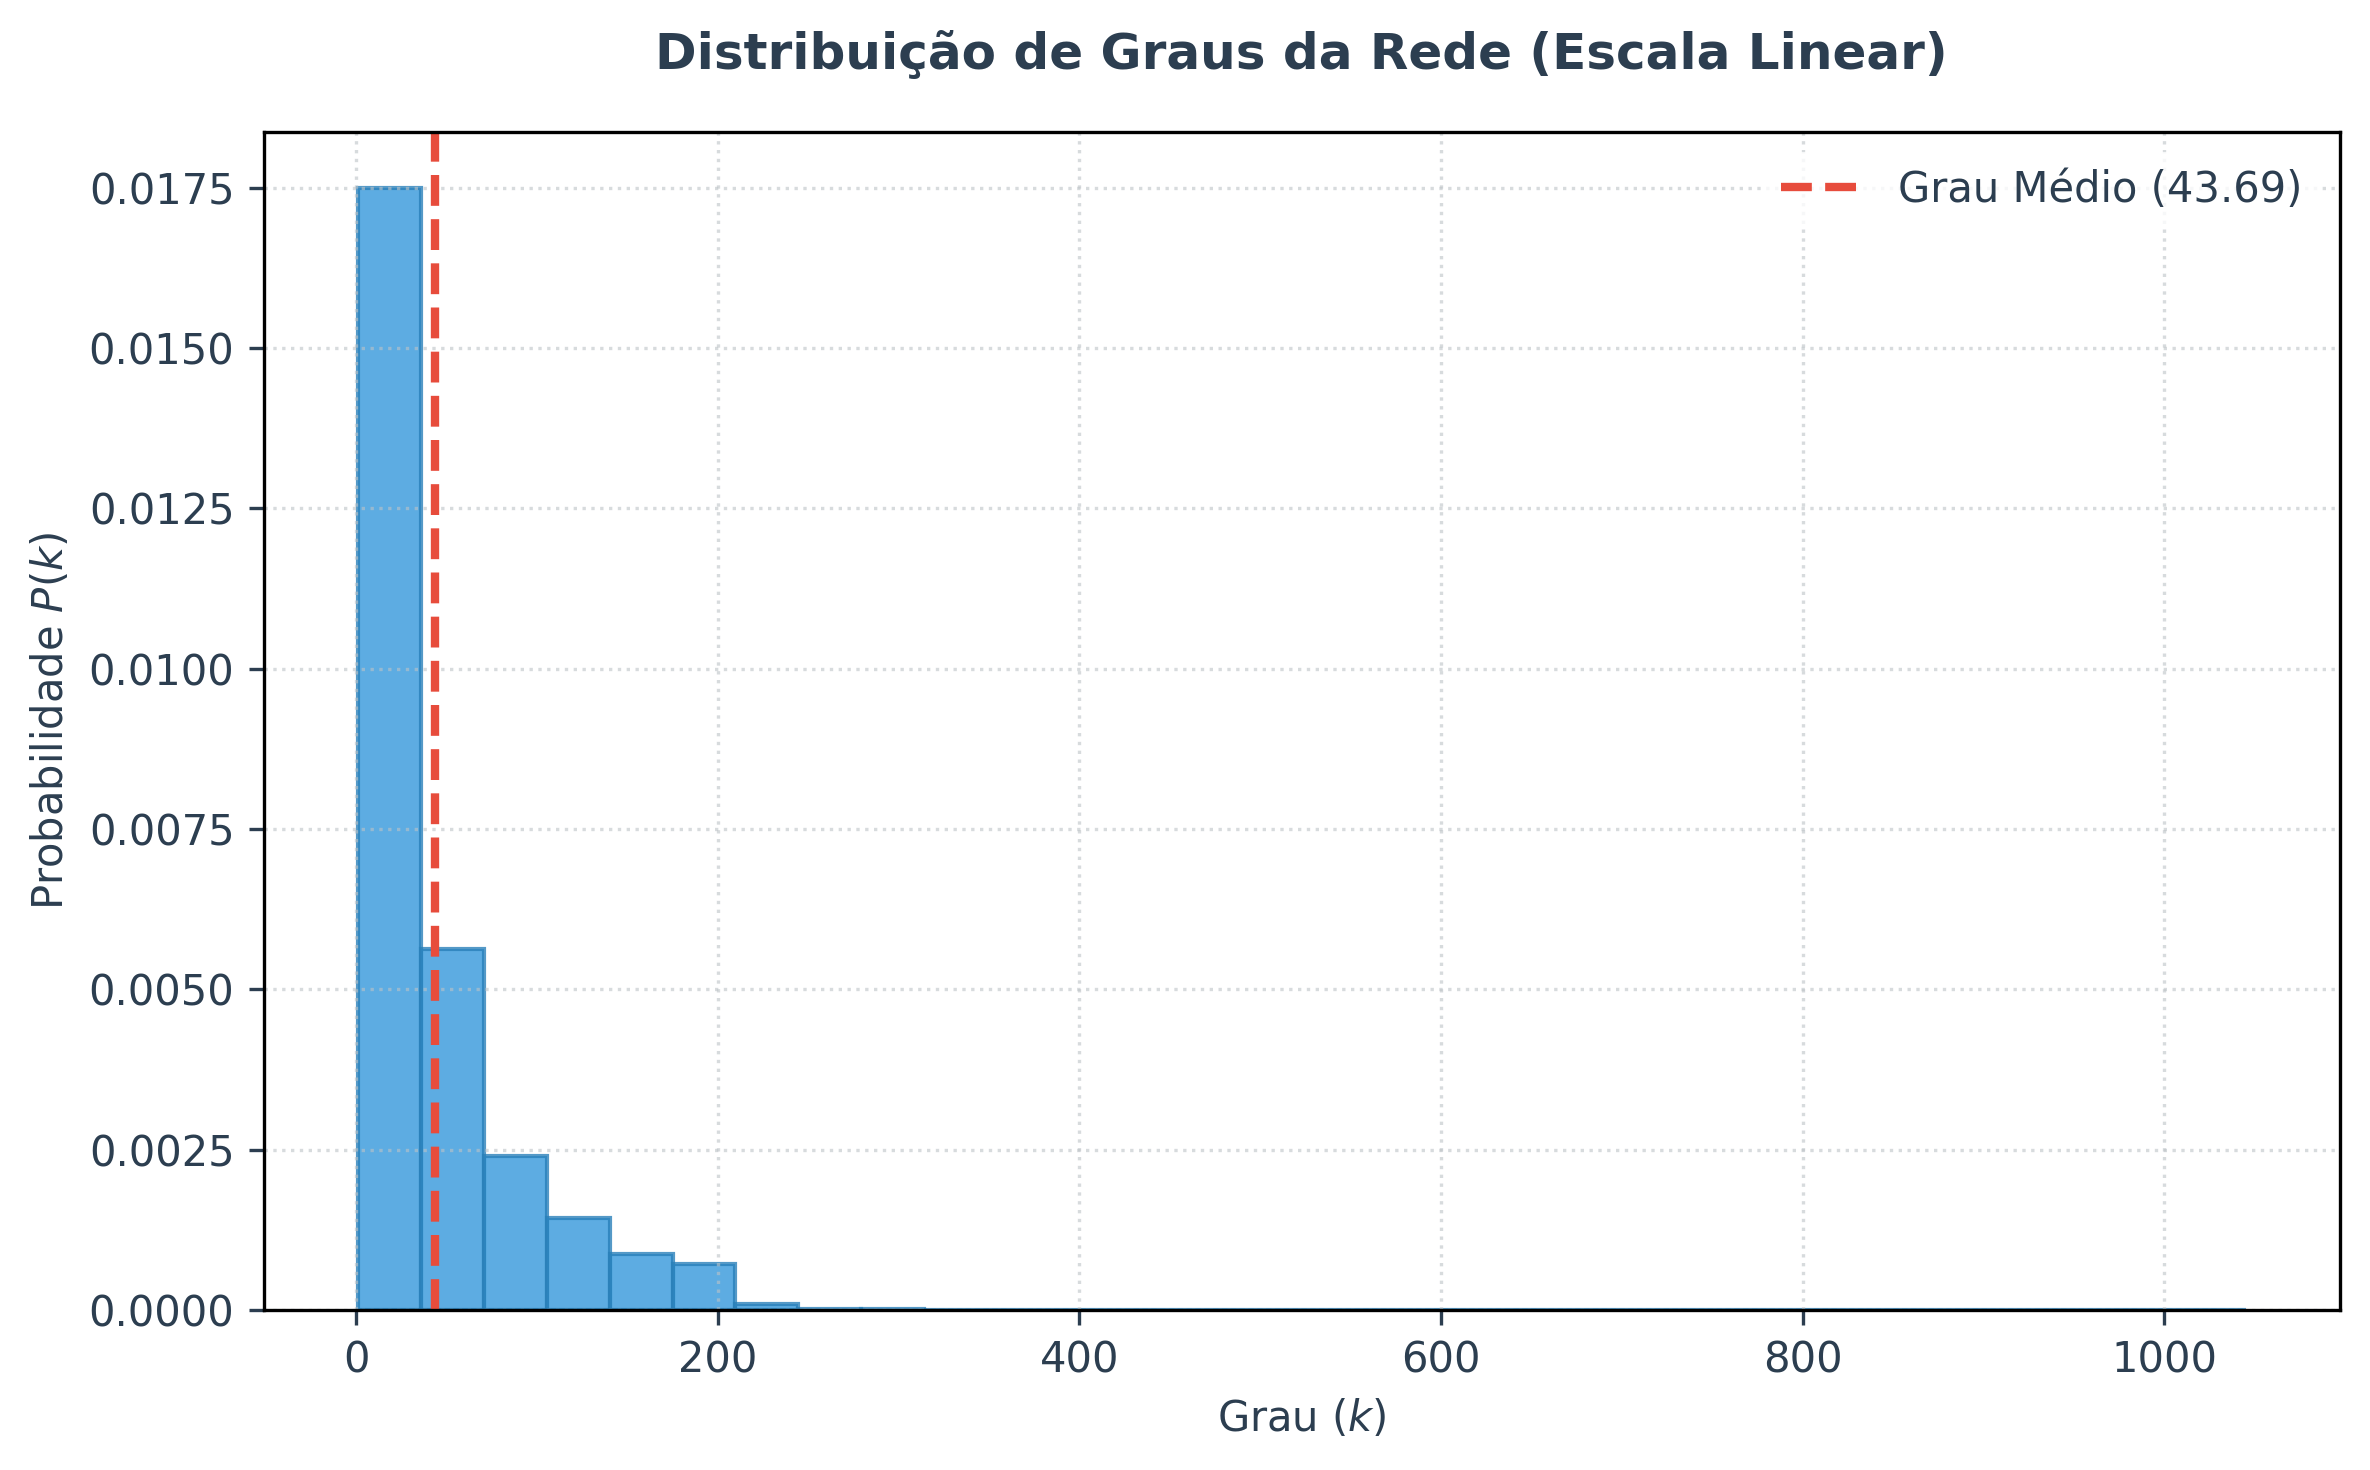

In [12]:
import matplotlib.pyplot as plt

# Configurar estilo visual premium
plt.figure(figsize=(8, 5), dpi=300)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['text.color'] = '#2c3e50'
plt.rcParams['axes.labelcolor'] = '#2c3e50'
plt.rcParams['xtick.color'] = '#2c3e50'
plt.rcParams['ytick.color'] = '#2c3e50'

# Plotar o histograma de densidade linear
plt.hist(graus, bins=30, color='#3498db', edgecolor='#2980b9', alpha=0.8, density=True)
plt.axvline(grau_medio, color='#e74c3c', linestyle='--', linewidth=2, label=f'Grau Médio ({grau_medio:.2f})')

plt.title('Distribuição de Graus da Rede (Escala Linear)', fontsize=12, fontweight='bold', pad=15, color='#2c3e50')
plt.xlabel('Grau ($k$)', fontsize=10)
plt.ylabel('Probabilidade $P(k)$', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6, color='#bdc3c7')
plt.legend(frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()

# Salvar o arquivo de imagem automaticamente em alta resolução antes de exibir
nome_arquivo_linear = "distribuicao_grau_linear.png"
plt.savefig(nome_arquivo_linear, dpi=300, bbox_inches='tight')
print(f"Gráfico salvo localmente na pasta como '{nome_arquivo_linear}' com sucesso!")

plt.show()


<div align="center">
  <img src="distribuicao_grau_linear.png" width="70%" alt="Visualização da Ego-Network do Hub 107" />
</div>

O gráfico em escala linear revela uma distribuição fortemente assimétrica e concentrada à esquerda. Percebe-se nítidamente que a maioria dos usuários possui um número reduzido de conexões, bem abaixo do grau médio de 43, marcado pela linha vermelha. Por outro lado, o histograma estende-se em outras barras à direita (como uma cauda), indicando a existência de uma minoria seleta de atores altamente conectados, os "hubs" estruturais, como o nó 107. Esse tipo de distribuição com forte assimetria e cauda longa à direita é conhecido como *heavy-tailed distribution*, sendo uma marca universal de redes de relacionamentos humanos reais.


### Distribuição de Graus (Escala Log-Log)
Como mais um material de apoio, a mesma distribuição em um gráfico em escala dupla logarítmica (log-log).


In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

# Contar frequências de cada grau único para P(k)
grau_counts = Counter(graus)
k = list(grau_counts.keys())
pk = [count / num_nos for count in grau_counts.values()]

# Configurar estilo visual premium
plt.figure(figsize=(8, 5), dpi=300)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['text.color'] = '#2c3e50'

# Plotar a dispersão em escala log-log
plt.scatter(k, pk, color='#2c3e50', alpha=0.7, edgecolors='#34495e', s=45, label='Dados do Facebook')
plt.xscale('log')
plt.yscale('log')

plt.title('Distribuição de Graus da Rede (Escala Log-Log)', fontsize=12, fontweight='bold', pad=15, color='#2c3e50')
plt.xlabel('Grau ($k$) - Escala Log', fontsize=10)
plt.ylabel('Probabilidade $P(k)$ - Escala Log', fontsize=10)
plt.grid(True, which="both", linestyle=':', alpha=0.6, color='#bdc3c7')
plt.legend(frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()

# Salvar o arquivo de imagem automaticamente em alta resolução antes de exibir
nome_arquivo_loglog = "distribuicao_grau_loglog.png"
plt.savefig(nome_arquivo_loglog, dpi=300, bbox_inches='tight')
print(f"Gráfico salvo localmente na pasta como '{nome_arquivo_loglog}' com sucesso!")

plt.show()


<div align="center">
  <img src="distribuicao_grau_loglog.png" width="70%" alt="Visualização da distribuição de graus em escala loglog" />
</div>


Ao plotarmos a probabilidade de grau $P(k)$ em escala dupla logarítmica (log-log), observamos que os pontos dispersos se distribuem de forma aproximadamente retilínea decrescente. A escala logarítmica expande a região dos graus baixos e contrai a longa cauda dos graus elevados, permitindo visualizar com clareza o comportamento da rede.
    
Esse alinhamento linear decrescente é a assinatura visual de uma distribuição de cauda pesada (*heavy-tailed*). Ela indica que a probabilidade $P(k)$ de encontrar um usuário com grau $k$ diminui à medida que o grau aumenta, mas essa redução ocorre de forma muito mais lenta do que em redes homogêneas.
    
Esse perfil de gráfico comprova a heterogeneidade estrutural da rede, indicando características típicas de uma Rede Livre de Escala (*Scale-Free*). A ausência de uma escala de grau "normal" diferencia esta rede de modelos homogêneos (onde a maioria dos nós se concentra próximo à média). Estruturalmente, a maior parte dos usuários possui poucas conexões, enquanto a conectividade global é concentrada em poucos nós com graus muito elevados, como o nó Ego 107 que possui 1.045 conexões.

## (c) Número de Componentes do Grafo

Na modelagem de redes, um grafo é classificado como conectado se existe ao menos um caminho interligando qualquer par de nós. Caso não exista, o grafo é considerado desconectado e se divide em subgrafos isolados chamados de componentes conectados. 

Um componente conectado é um conjunto de nós interligados entre si por caminhos, mas que não possuem nenhuma conexão com os nós dos demais componentes da rede. 

A análise do número e do tamanho dessas divisões indica se a rede funciona de forma integrada e coesa ou se está fragmentada em ilhas isoladas de informação.

In [16]:
# 1. Calcular o número de componentes conectados e verificar se o grafo é conectado
is_conectado = nx.is_connected(grafo)
componentes = list(nx.connected_components(grafo))
num_componentes = len(componentes)

# 2. Obter os tamanhos dos componentes ordenados de forma decrescente
tamanhos_componentes = sorted([len(c) for c in componentes], reverse=True)

# 3. Exibir os resultados obtidos
print(f"Grafo é conectado? {is_conectado}")
print(f"Número total de componentes: {num_componentes}")
print(f"Tamanho do maior componente: {tamanhos_componentes[0]}")
if num_componentes > 1:
    print(f"Tamanhos dos 5 maiores componentes: {tamanhos_componentes[:5]}")

Grafo é conectado? True
Número total de componentes: 1
Tamanho do maior componente: 4039


A execução do algoritmo revela que o grafo possui exatamente 1 componente conectado, contendo todos os 4.039 nós do dataset. Esse resultado comprova que o grafo é totalmente conectado, logo existe ao menos um caminho físico que interliga qualquer par de usuários na rede.

Em redes de interação humana, a presença de uma componente gigante que unifica a grande maioria dos nós é um comportamento padrão. No nosso dataset, devido à forma de coleta estruturada a partir da sobreposição de 10 ego-networks completas de voluntários altamente conectados, a rede possui um único bloco totalmente integrado.

A existência de um único componente conexo garante que a informação pode propagar-se de qualquer actor para qualquer outro na rede, sem barreiras estruturais ou ilhas isoladas de usuários.

## (d) Coeficiente de Clusterização do Grafo

O coeficiente de clusterização é uma métrica que quantifica a propensão dos vértices de um grafo de se agruparem localmente em comunidades altamente conectadas, conhecidas popularmente como **panelinhas**. 

Para um vértice i com grau n_i (onde n_i representa o seu número de vizinhos), o coeficiente de clusterização local C_i é definido como a fração de conexões existentes entre seus vizinhos em relação ao total de conexões possíveis entre eles. A fórmula matemática para o cálculo de C_i é dada por:

$$C_i = \frac{2 e_i}{n_i (n_i - 1)}$$

Onde e_i representa o número de arestas que de fato conectam os vizinhos do nó i entre si. O valor de C_i varia no intervalo [0, 1], onde C_i = 1 indica que todos os vizinhos do nó i são conectados entre si, e C_i = 0 indica que nenhum de seus amigos se conhece. Para nós com grau menor que 2, define-se C_i = 0.

O coeficiente de clusterização global do grafo representa a média dos coeficientes locais de todos os nós do grafo, sendo calculado por:

$$C = \frac{1}{N} \sum_{i=1}^{N} C_i$$

Onde N é o número total de nós no grafo. Esse coeficiente serve para avaliar o nível geral de coesão da rede.

Coeficiente de clusterização global (médio): 0.605547
Mínimo coeficiente de clusterização local: 0.000000
Máximo coeficiente de clusterização local: 1.000000
Mediana dos coeficientes de clusterização local: 0.600000


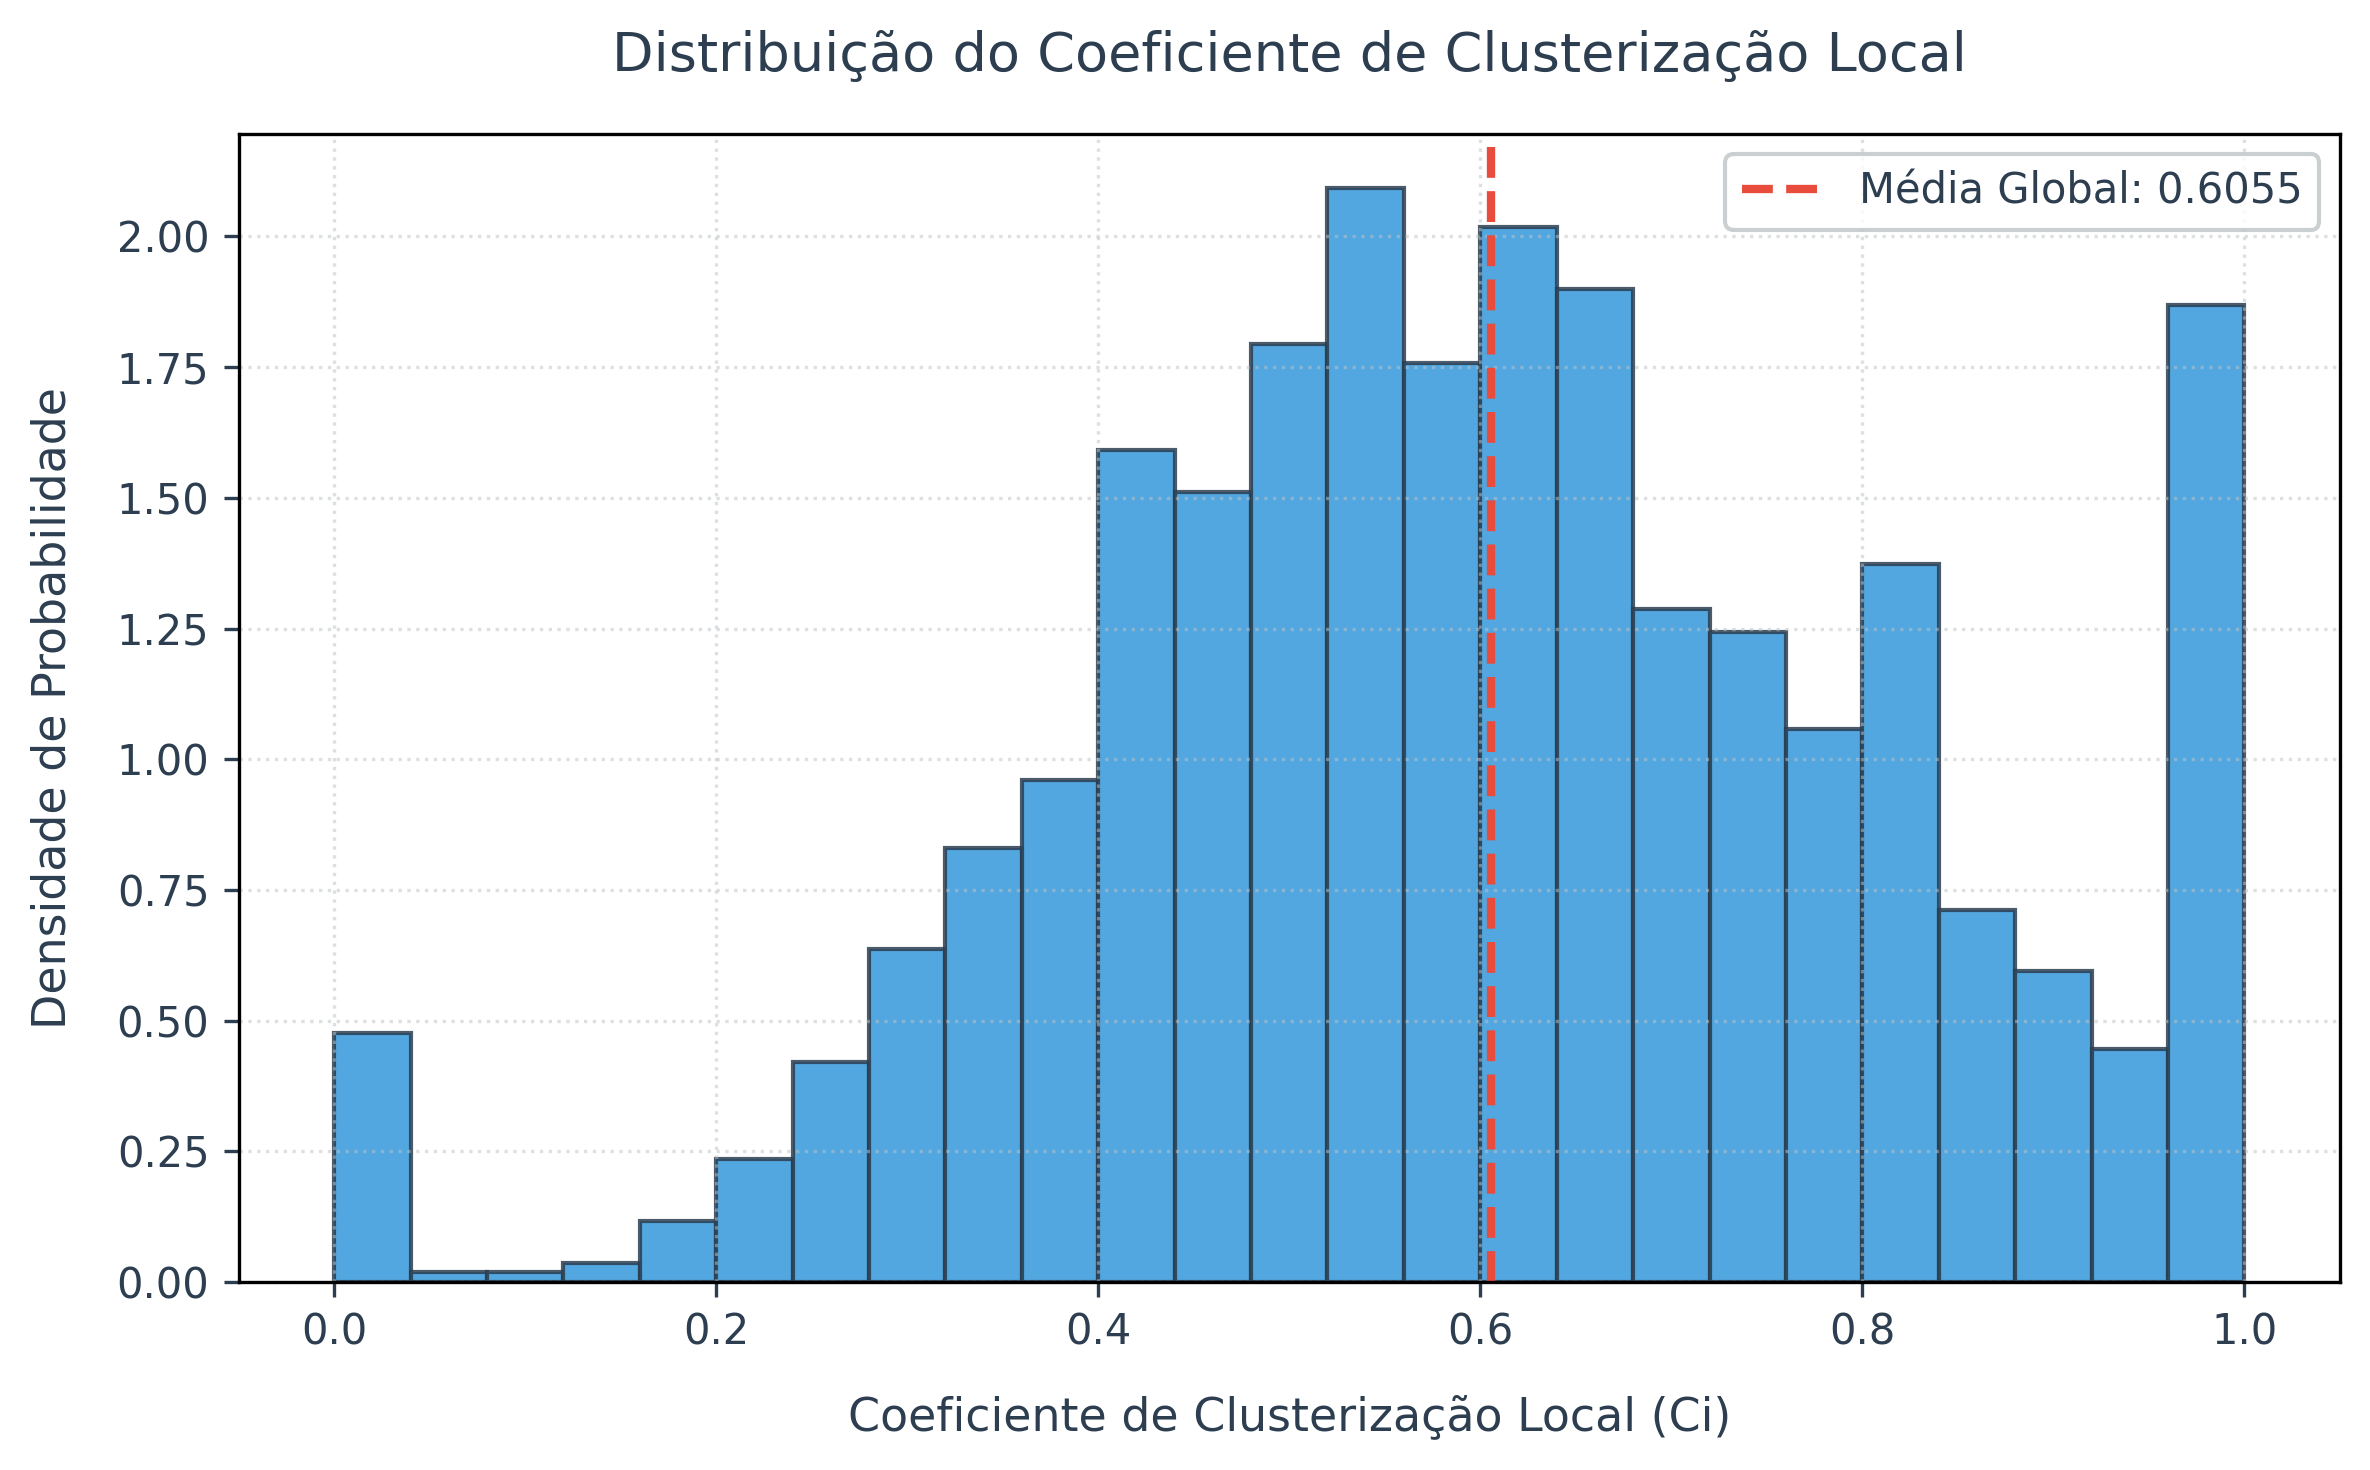

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Calcular o coeficiente de clusterização de cada nó
coefs_locais = nx.clustering(grafo)
valores_coefs = list(coefs_locais.values())

# 2. Calcular o coeficiente de clusterização global (médio) do grafo
coef_global = nx.average_clustering(grafo)

# 3. Exibir as estatísticas descritivas no console
print(f"Coeficiente de clusterização global (médio): {coef_global:.6f}")
print(f"Mínimo coeficiente de clusterização local: {min(valores_coefs):.6f}")
print(f"Máximo coeficiente de clusterização local: {max(valores_coefs):.6f}")
print(f"Mediana dos coeficientes de clusterização local: {np.median(valores_coefs):.6f}")

# 4. Plotar a distribuição do coeficiente de clusterização local
plt.figure(figsize=(8, 5), dpi=300)
plt.rcParams['font.family'] = 'sans-serif'

# Plotar o histograma com densidade de probabilidade
plt.hist(valores_coefs, bins=25, color='#3498db', edgecolor='#2c3e50', alpha=0.85, density=True)

# Adicionar linha vertical indicando a média global
plt.axvline(coef_global, color='#e74c3c', linestyle='--', linewidth=2, label=f"Média Global: {coef_global:.4f}")

# Personalizar títulos e eixos com design limpo e moderno
plt.title("Distribuição do Coeficiente de Clusterização Local", fontsize=13, pad=15, color='#2c3e50')
plt.xlabel("Coeficiente de Clusterização Local (Ci)", fontsize=11, labelpad=10, color='#2c3e50')
plt.ylabel("Densidade de Probabilidade", fontsize=11, labelpad=10, color='#2c3e50')

# Grid sutil para auxiliar a leitura
plt.grid(True, linestyle=':', alpha=0.5, color='#bdc3c7')
plt.legend(frameon=True, facecolor='white', edgecolor='#bdc3c7')

# Ajustar layout para evitar cortes
plt.tight_layout()

# Salvar o gráfico em alta resolução antes de exibir
plt.savefig("distribuicao_clusterizacao.png", dpi=300, bbox_inches='tight')
plt.show()

<div align="center">
  <img src="distribuicao_clusterizacao.png" width="70%" alt="Visualização da distribuição do coeficiente de clusterização" />
</div>


A execução dos cálculos revela um coeficiente de $\approx$ 0,6055 (ou 60,55%) e uma mediana local de 0,6. Isso significa que, na média, existe uma probabilidade de 60,55% de que dois amigos de um determinado usuário do Facebook também sejam amigos entre si. Esse valor extremamente elevado comprova o funcionamento prático do **Fechamento Triádico**. Sob esse princípio, se dois atores possuem um amigo em comum, a chance de eles estabelecerem uma amizade mútua é alta.

O resultado obtido "afasta" o grafo de modelos aleatórios. Em uma rede aleatória que tem a mesma densidade, o coeficiente de clusterização esperado seria igual à densidade da rede, que é de apenas 1,08%. O coeficiente medido na rede é cerca de 56 vezes maior do que o esperado em uma rede aleatória. Essa diferença confirma a teoria de que as redes sociais humanas possuem um coeficiente de agrupamento global significativamente maior que redes puramente aleatórias, refletindo a organização natural das interações humanas em comunidades locais fortemente coesas e panelinhas de amizade.

O histograma da distribuição local complementa esses dados ao evidenciar que o agrupamento local não é uniforme ao longo da rede. A visualização revela picos nos extremos de 0,0 e 1,0, indicando que enquanto alguns indivíduos estão inseridos em comunidades perfeitamente fechadas, outros possuem amigos totalmente desconectados entre si.

## (e) Distribuição do Tamanho dos Componentes do Grafo

Como comprovado na alternativa (c), a rede social analisada possui apenas 1 componente conectado, o qual compreende todos os 4.039 nós do grafo. De acordo com o enunciado, a plotagem da distribuição pode ser dispensada nesse caso.

## (f) Distribuição de *overlap*

A sobreposição de vizinhança (overlap) é uma métrica que quantifica a força e a redundância de uma conexão entre dois nós em uma rede de maneira estrutural. Semanticamente, ela mede o percentual de amigos em comum que duas pessoas conectadas possuem.

Para cada par de nós u e v conectados por uma aresta (u, v) em E, o overlap da vizinhança é calculado dividindo-se o número de vizinhos compartilhados por ambos pelo número total de vizinhos únicos de u e/ou v, excluindo os próprios nós u e v. A fórmula matemática é dada por:

$$\text{Overlap}(u, v) = \frac{|\Gamma(u) \cap \Gamma(v)|}{|(\Gamma(u) \cup \Gamma(v)) \setminus \{u, v\}|}$$

Onde $\Gamma(u)$ e $\Gamma(v)$ representam os conjuntos de vizinhos dos nós u e v, respectivamente. 

O valor do overlap varia no intervalo [0, 1]. Um overlap igual a 1,0 indica que todos os contatos de u são amigos de v (e vice-versa), caracterizando uma conexão de altíssima redundância social. Por outro lado, um overlap igual a 0,0 indica que os dois nós não possuem absolutamente nenhum amigo em comum além de si mesmos. 

Em redes complexas, arestas com overlap igual a zero são a definição matemática exata de pontes locais, que desempenham um papel crucial como elos fracos que conectam diferentes partes da rede social.

Total de arestas analisadas: 88234
Sobreposição média de vizinhança: 0.377900
Mediana da sobreposição: 0.364532
Mínimo overlap encontrado: 0.000000
Máximo overlap encontrado: 1.000000
Quantidade de pontes locais exatas (overlap = 0.0): 78 (fração: 0.088401%)
Quantidade de Laços Fracos (overlap <= 0.1): 9077 (fração: 10.287418%)
Quantidade de Laços Fortes (overlap > 0.1): 79157 (fração: 89.712582%)


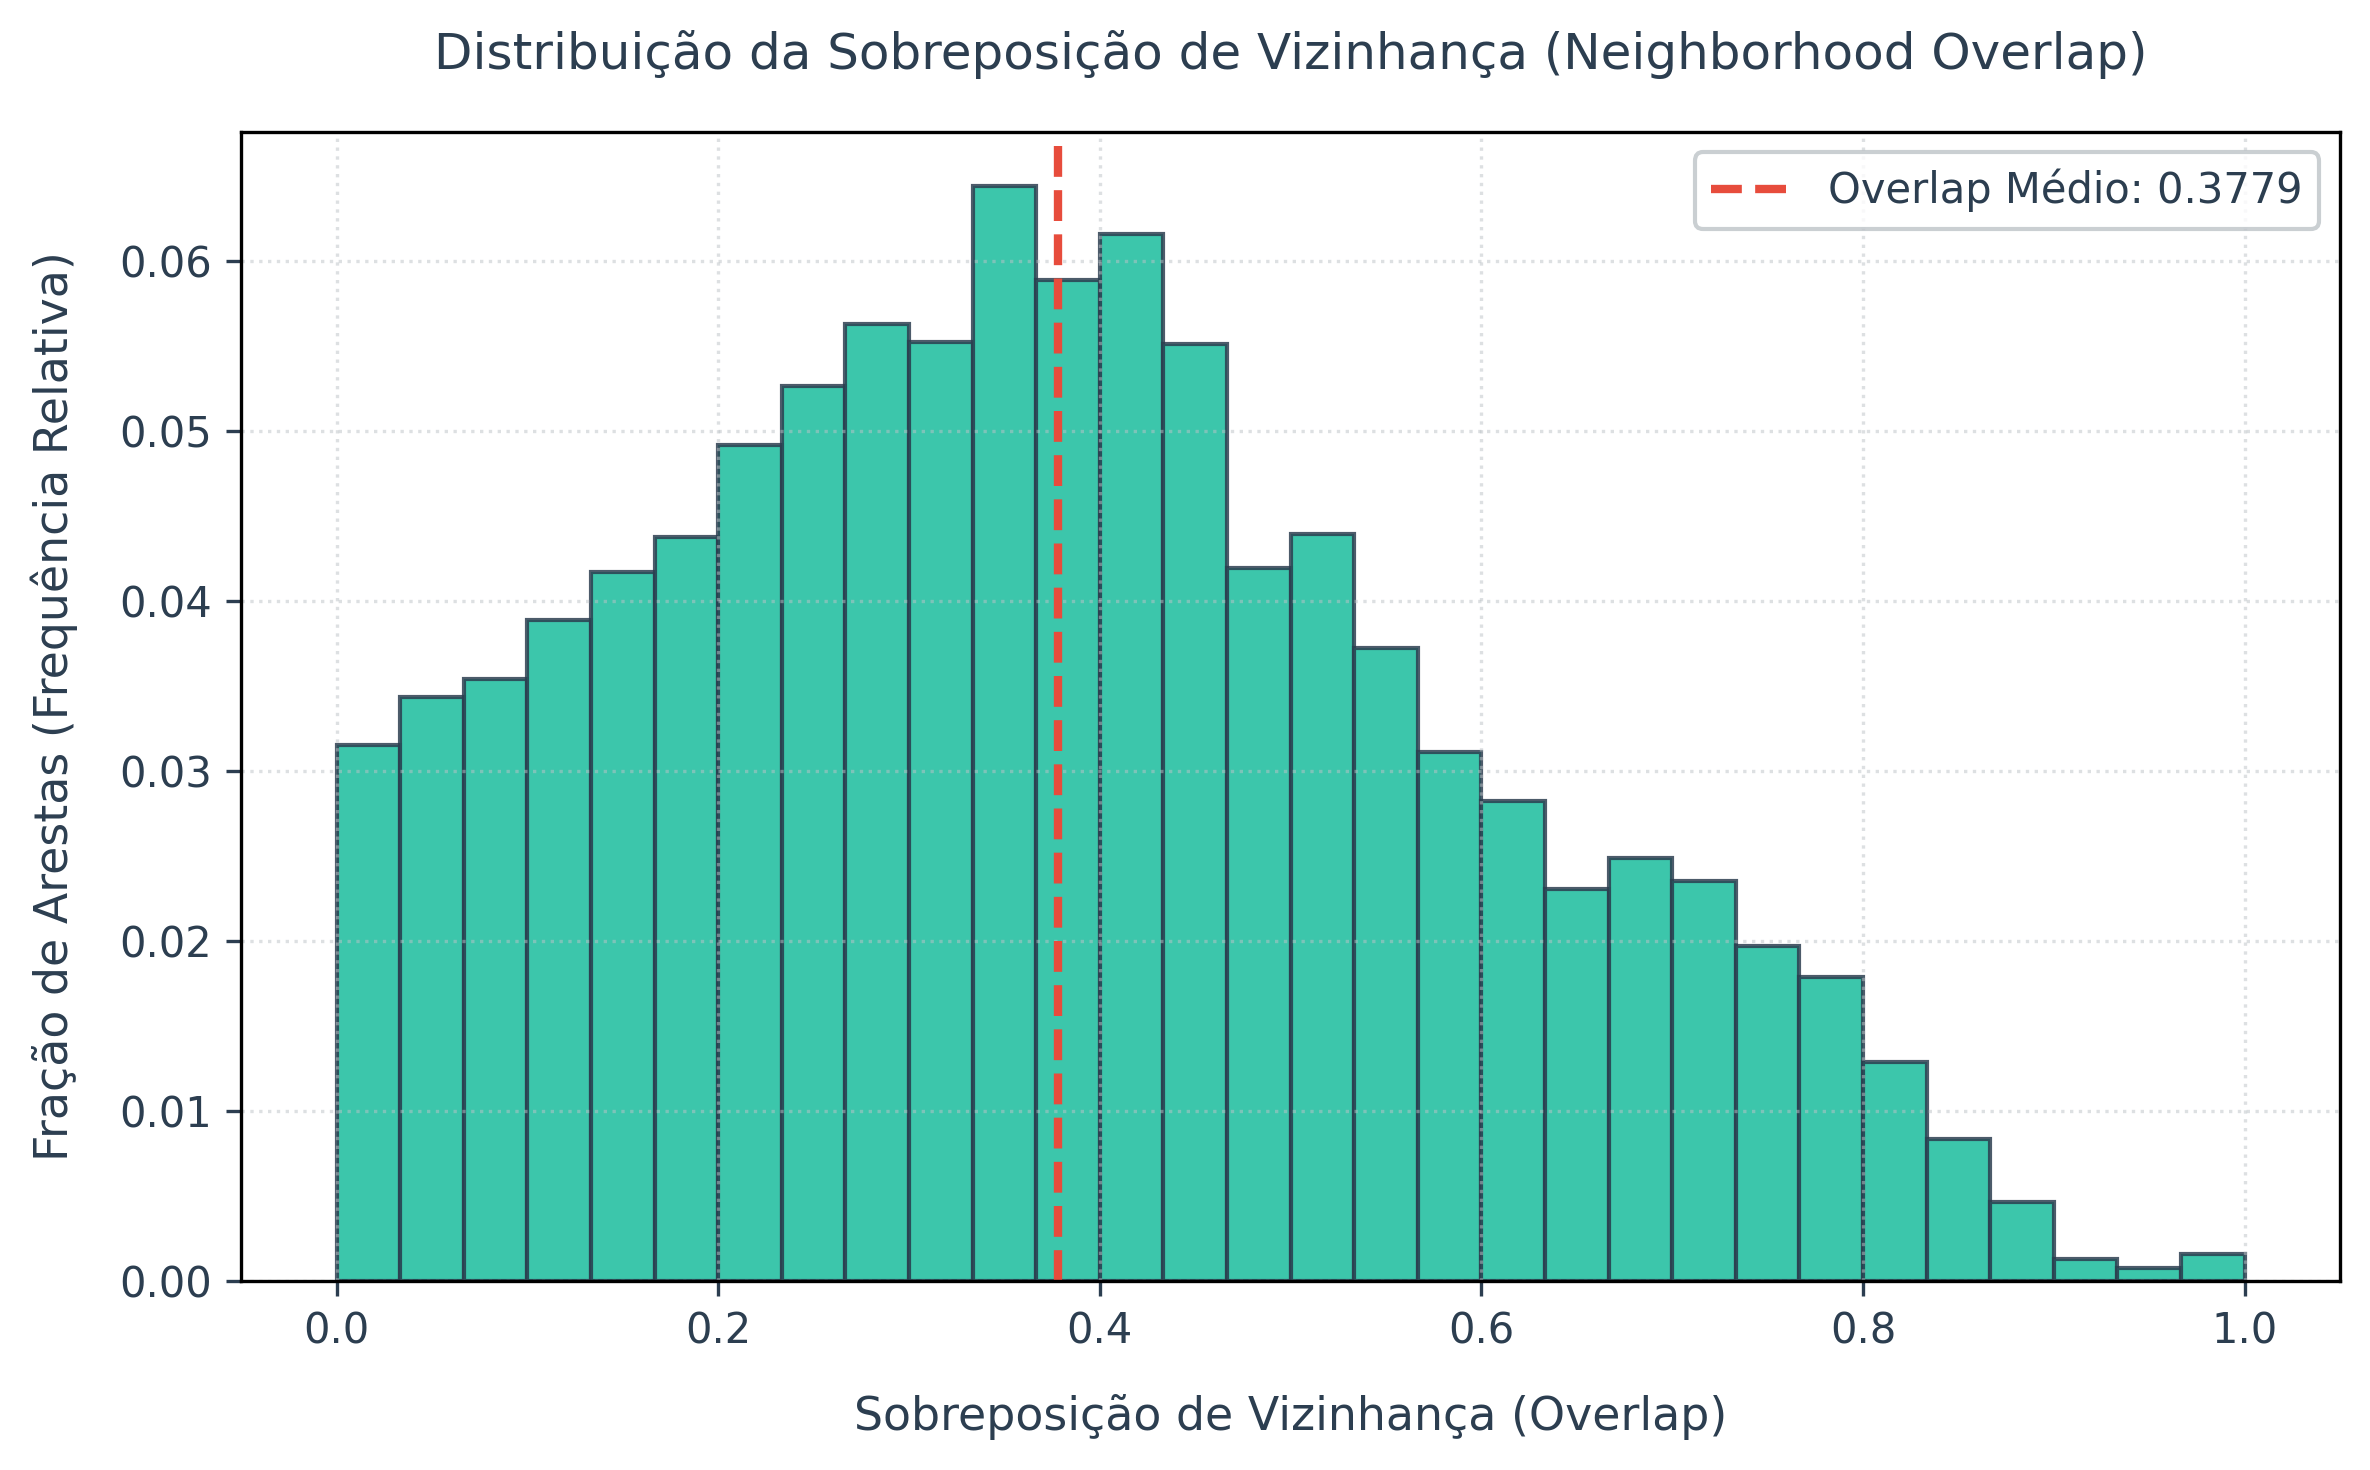

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Calcular o overlap de vizinhança para cada aresta (par de nós conectados)
overlaps = []
for u, v in grafo.edges():
    vizinhos_u = set(grafo.neighbors(u))
    vizinhos_v = set(grafo.neighbors(v))
    
    intersecao = vizinhos_u.intersection(vizinhos_v)
    uniao = vizinhos_u.union(vizinhos_v) - {u, v}
    
    if len(uniao) > 0:
        overlap_val = len(intersecao) / len(uniao)
    else:
        overlap_val = 0.0
    overlaps.append(overlap_val)

# 2. Exibir estatísticas descritivas no console, incluindo classificação de laços
media_overlap = np.mean(overlaps)
mediana_overlap = np.median(overlaps)
min_overlap = min(overlaps)
max_overlap = max(overlaps)
pontes_locais = sum(1 for x in overlaps if x == 0.0)

# Classificar em Laços Fracos (Weak Ties) e Laços Fortes (Strong Ties) com base no overlap
# Adotamos o limiar de overlap <= 0.1 para Laços Fracos e > 0.1 para Laços Fortes
lacos_fracos = sum(1 for x in overlaps if x <= 0.1)
lacos_fortes = sum(1 for x in overlaps if x > 0.1)

print(f"Total de arestas analisadas: {len(overlaps)}")
print(f"Sobreposição média de vizinhança: {media_overlap:.6f}")
print(f"Mediana da sobreposição: {mediana_overlap:.6f}")
print(f"Mínimo overlap encontrado: {min_overlap:.6f}")
print(f"Máximo overlap encontrado: {max_overlap:.6f}")
print(f"Quantidade de pontes locais exatas (overlap = 0.0): {pontes_locais} (fração: {pontes_locais / len(overlaps):.6%})")
print(f"Quantidade de Laços Fracos (overlap <= 0.1): {lacos_fracos} (fração: {lacos_fracos / len(overlaps):.6%})")
print(f"Quantidade de Laços Fortes (overlap > 0.1): {lacos_fortes} (fração: {lacos_fortes / len(overlaps):.6%})")

# 3. Plotar a distribuição da sobreposição de vizinhança
plt.figure(figsize=(8, 5), dpi=300)
plt.rcParams['font.family'] = 'sans-serif'

# Criar pesos para exibir a fração de arestas (frequência relativa) no eixo Y
pesos = np.ones_like(overlaps) / len(overlaps)
plt.hist(overlaps, bins=30, color='#1abc9c', edgecolor='#2c3e50', alpha=0.85, weights=pesos)

# Adicionar linha vertical indicando a média
plt.axvline(media_overlap, color='#e74c3c', linestyle='--', linewidth=2, label=f"Overlap Médio: {media_overlap:.4f}")

# Personalizar títulos e eixos com design limpo e moderno
plt.title("Distribuição da Sobreposição de Vizinhança (Neighborhood Overlap)", fontsize=12, pad=15, color='#2c3e50')
plt.xlabel("Sobreposição de Vizinhança (Overlap)", fontsize=11, labelpad=10, color='#2c3e50')
plt.ylabel("Fração de Arestas (Frequência Relativa)", fontsize=11, labelpad=10, color='#2c3e50')

# Grid sutil para auxiliar a leitura
plt.grid(True, linestyle=':', alpha=0.5, color='#bdc3c7')
plt.legend(frameon=True, facecolor='white', edgecolor='#bdc3c7')

# Ajustar layout para evitar cortes
plt.tight_layout()

# Salvar o gráfico em alta resolução antes de exibir
plt.savefig("distribuicao_overlap.png", dpi=300, bbox_inches='tight')
plt.show()


<div align="center">
  <img src="distribuicao_overlap.png" width="70%" alt="Visualização da distribuição do coeficiente de overlap" />
</div>


A execução dos cálculos revela uma sobreposição média de vizinhança de aproximadamente 0,3779 (ou 37,79%) e uma mediana de 0,3645. Isso significa que, em média, qualquer par de amigos conectados no grafo compartilha cerca de 37,79% de todos os seus amigos combinados na rede. Esse valor é expressivamente alto, indicando uma elevada redundância local nas conexões do Facebook.

A análise do histograma demonstra que a maioria das arestas possui overlaps concentrados na faixa intermediária e alta (entre 0,2 e 0,6). Esse comportamento é uma consequência direta do alto coeficiente de agrupamento estudado na seção 2(d), reforçando a ideia de que a rede é estruturada em comunidades locais coesas formadas pelo fechamento triádico.

Os laços fortes representam a grande maioria das conexões na rede, totalizando 79.157 arestas (89,712% do total) com overlap superior a 0,1. Essas relações altamente redundantes estão inseridas no interior de comunidades locais coesas e densas, onde os amigos de um indivíduo tendem a ser amigos entre si, oferecendo suporte social e coesão local.

Já os laços fracos representam 9.077 arestas (10,288% do total) com overlap menor ou igual a 0,1. Sociologicamente, essas conexões com poucos amigos em comum indicam relacionamentos entre indivíduos de círculos sociais distintos. Embora representem uma minoria, os laços fracos desempenham um papel crucial na rede, funcionando como pontes informacionais que viabilizam a difusão de novas ideias e conhecimentos entre diferentes comunidades, reduzindo o diâmetro global da rede.

No extremo esquerdo do gráfico, com overlap exatamente igual a 0, existem 78 pontes locais exatas representando apenas 0,088% de todos os links. Essas conexões são o caso limite de laços fracos, onde os dois indivíduos não possuem absolutamente nenhum amigo em comum além de si mesmos. Elas atuam como os únicos elos físicos que mantêm as diferentes ego-networks integradas em um único componente gigante conexo.


## (g) Distância Média e Distribuição de Distâncias

A distância entre dois nós em um grafo é definida como o comprimento do menor caminho entre eles, ou seja, o número mínimo de arestas necessárias para conectá-los. 

Para um par de nós u e v em V, denotamos a menor distância como d(u, v). Se u = v, então d(u, v) = 0. Caso não haja caminho entre eles, d(u, v) é infinito, mas em grafos totalmente conectados (como o nosso subgrafo do Facebook), todas as distâncias entre pares de nós são finitas.

A distância média do grafo é o valor médio de todas as distâncias de caminhos mínimos entre todos os pares possíveis de nós distintos na rede. Ela representa quão próximos os nós estão uns dos outros globalmente e é calculada matematicamente pela seguinte fórmula:

$$\langle d \rangle = \frac{2}{N(N - 1)} \sum_{u < v} d(u, v)$$

Onde N representa o número total de nós na rede. 

Outro parâmetro de interesse é o diâmetro do grafo (D), que representa a maior distância de caminho mínimo possível entre qualquer par de nós do grafo:

$$D = \max_{u, v \in V} d(u, v)$$

A distribuição das distâncias complementa essa análise ao mostrar a frequência de caminhos de cada comprimento, permitindo avaliar a homogeneidade da proximidade estrutural na rede.

Total de caminhos mínimos calculados: 8154741
Distância média da rede: 3.692507
Diâmetro da rede (maior distância): 8
Frequência absoluta por distância:
  Distância 1: 88234 caminhos (fração: 1.0820%)
  Distância 2: 1358067 caminhos (fração: 16.6537%)
  Distância 3: 1990926 caminhos (fração: 24.4143%)
  Distância 4: 2930780 caminhos (fração: 35.9396%)
  Distância 5: 1282585 caminhos (fração: 15.7281%)
  Distância 6: 338607 caminhos (fração: 4.1523%)
  Distância 7: 157732 caminhos (fração: 1.9342%)
  Distância 8: 7810 caminhos (fração: 0.0958%)


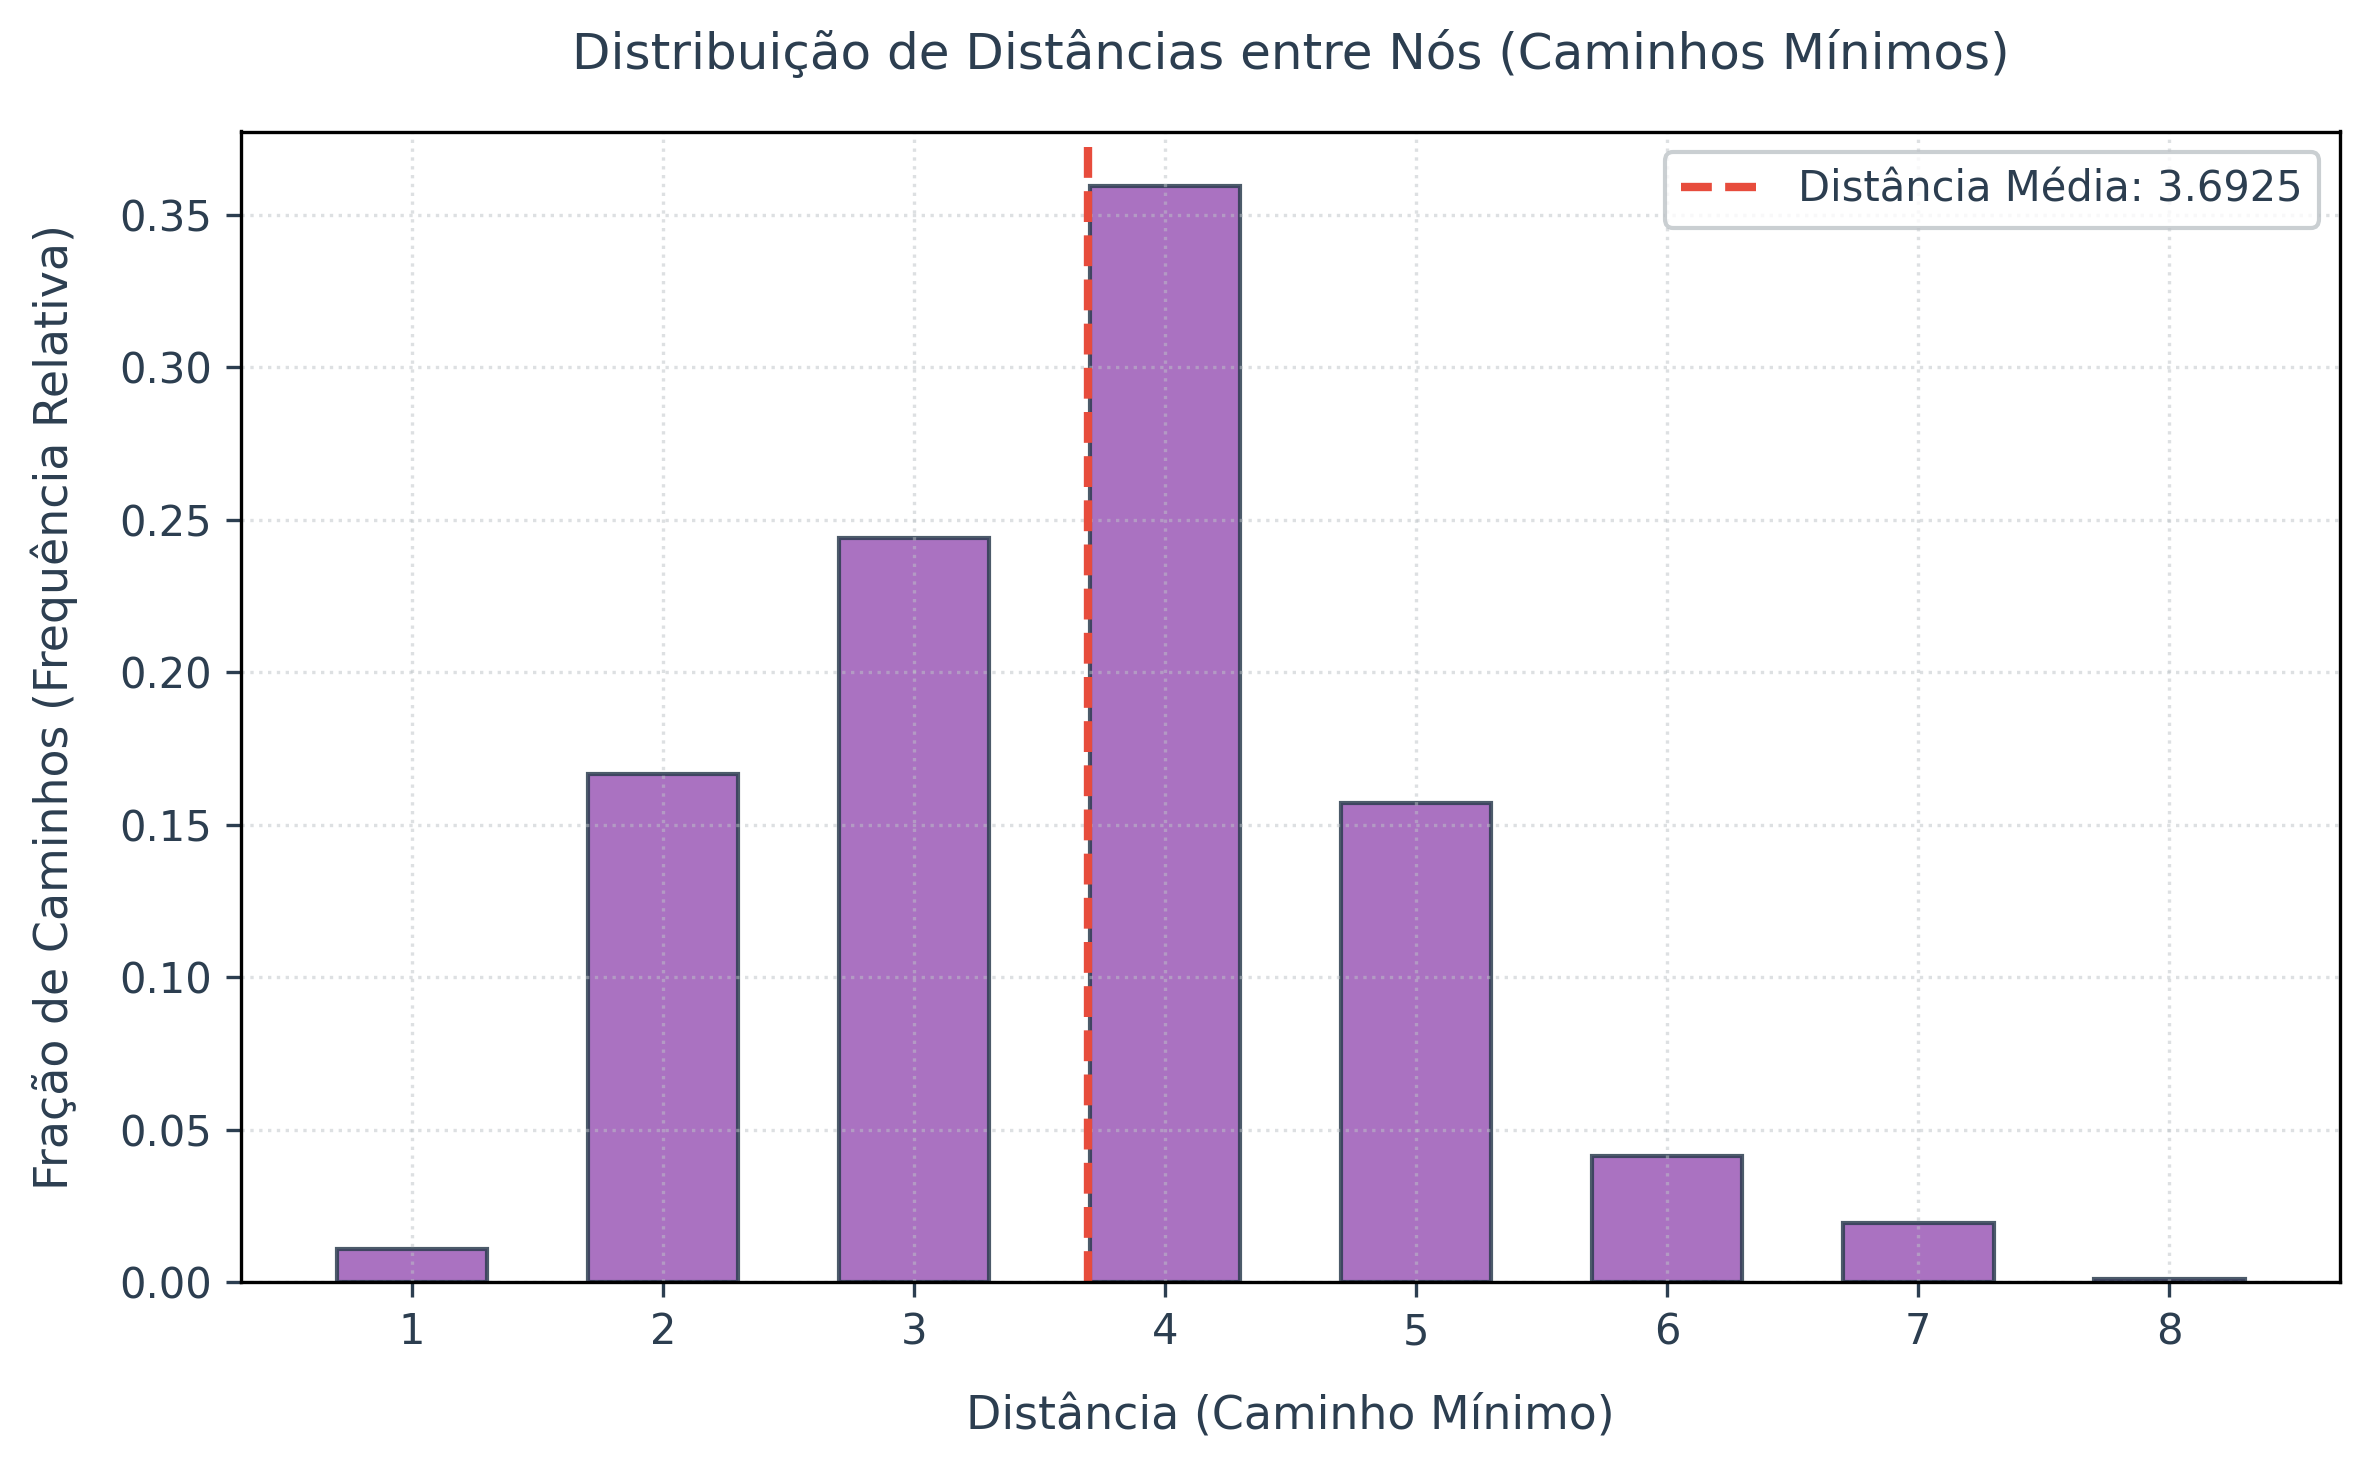

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import collections

# 1. Calcular o caminho mínimo entre todos os pares de nós (all pairs shortest path)
# O cálculo envolve realizar uma busca em largura (BFS) a partir de cada nó
distâncias_caminhos = []
for no, caminhos in nx.all_pairs_shortest_path_length(grafo):
    for destino, comprimento in caminhos.items():
        if no < destino:  # Evita duplicidade para grafos não-direcionados
            distâncias_caminhos.append(comprimento)

# 2. Calcular estatísticas globais de distância
distancia_media = np.mean(distâncias_caminhos)
diametro = max(distâncias_caminhos)
contagem_distâncias = collections.Counter(distâncias_caminhos)

# 3. Exibir os resultados obtidos no console
print(f"Total de caminhos mínimos calculados: {len(distâncias_caminhos)}")
print(f"Distância média da rede: {distancia_media:.6f}")
print(f"Diâmetro da rede (maior distância): {diametro}")
print("Frequência absoluta por distância:")
for dist, freq in sorted(contagem_distâncias.items()):
    print(f"  Distância {dist}: {freq} caminhos (fração: {freq/len(distâncias_caminhos):.4%})")

# 4. Plotar a distribuição do tamanho das distâncias
plt.figure(figsize=(8, 5), dpi=300)
plt.rcParams['font.family'] = 'sans-serif'

# Configurar dados do gráfico de barras
x_valores = sorted(contagem_distâncias.keys())
y_frações = [contagem_distâncias[x] / len(distâncias_caminhos) for x in x_valores]

# Plotar gráfico de barras para variável discreta
plt.bar(x_valores, y_frações, color='#9b59b6', edgecolor='#2c3e50', alpha=0.85, width=0.6)

# Adicionar linha vertical indicando a distância média
plt.axvline(distancia_media, color='#e74c3c', linestyle='--', linewidth=2, label=f"Distância Média: {distancia_media:.4f}")

# Personalizar títulos e eixos com design limpo e moderno
plt.title("Distribuição de Distâncias entre Nós (Caminhos Mínimos)", fontsize=12, pad=15, color='#2c3e50')
plt.xlabel("Distância (Caminho Mínimo)", fontsize=11, labelpad=10, color='#2c3e50')
plt.ylabel("Fração de Caminhos (Frequência Relativa)", fontsize=11, labelpad=10, color='#2c3e50')
plt.xticks(x_valores)

# Grid sutil para auxiliar a leitura
plt.grid(True, linestyle=':', alpha=0.5, color='#bdc3c7')
plt.legend(frameon=True, facecolor='white', edgecolor='#bdc3c7')

# Ajustar layout para evitar cortes
plt.tight_layout()

# Salvar o gráfico em alta resolução antes de exibir
plt.savefig("distribuicao_distancias.png", dpi=300, bbox_inches='tight')
plt.show()

<div align="center">
  <img src="distribuicao_distancias.png" width="70%" alt="Visualização da distribuição de distâncias" />
</div>


A análise dos caminhos mínimos do grafo revela os seguintes resultados:

* Distância Média: O valor médio das menores distâncias entre os usuários é de aproximadamente 3,6925 arestas. Isso indica que qualquer par de atores na rede está separado por menos de 4 conexões de amizade em média. Semanticamente, a somatória das distâncias d(u,v) é mantida extremamente baixa.

* Diâmetro da Rede: O diâmetro medido é igual a 8. Isso define o limite máximo absoluto de separação topológica entre quaisquer dois membros na rede social analisada.

* Distribuição de Distâncias: O gráfico mostra que a proximidade é um fenômeno generalizado em toda a rede. A maior frequência de caminhos mínimos ocorre em distância 4 (35,94%), seguida de distância 3 (24,41%) e distância 2 (16,65%). O fato de mais de 93% de todos os caminhos possíveis possuírem comprimento igual ou menor que 5 comprova que a proximidade média não é influenciada por distorções locais, sendo uma característica global da rede.

* Explicação Topológica: A proximidade observada é justificada pelos hubs formados pelos egos centrais das dez ego-networks coletadas. A fusão e sobreposição desses círculos sociais geram atalhos estruturais de alta conectividade que interligam comunidades distantes e evitam o aumento das distâncias globais na rede.

* Propriedade de Mundo Pequeno (*Small-World*): Os valores empíricos curtos validam a teoria do Mundo Pequeno. Nessa teoria, a distância média da rede escala de forma logarítmica com o número total de nós, resultando em caminhos globais curtos mesmo em grafos de grande porte. Isso também é validado pelo gráfico vide a distribuição de caminhos entre os nós estarem concentrados em caminhos curtos, revelando os efeitos de possuir as ego-networks nessa rede.



## (h) Visualização do Grafo

A visualização de redes complexas é uma ferramenta essencial para a análise exploratória, permitindo identificar espacialmente padrões macroscópicos que as métricas numéricas não revelam de forma isolada, como a presença de comunidades, a centralidade de nós e a distribuição de densidade local.

Plotar a rede completa do Facebook contendo 4.039 nós e 88.234 arestas em uma única ferramenta de plotagem estática (como o Matplotlib) apresenta um desafio de legibilidade: o excesso de conexões sobrepostas gera um novelo de conexões congestionado (conhecido na literatura como hairball). Para contornar essa limitação e obter uma representação de alta legibilidade, selecionamos quatro ego-networks com diferentes tamanhos e estruturas para exibição: Ego 107 (super-hub, k=1045), Ego 1912 (grande hub, k=755), Ego 0 (médio hub, k=347) e Ego 348 (pequeno hub, k=229).

Abaixo, apresentamos uma visualização espacializada comparativa em um painel de grade 2x2. Os nós de cada subgrafo são dimensionados e coloridos usando o colormap plasma com base nos seus graus locais, destacando a estrutura centro-periferia e a diversidade de densidade local de cada ego-network.

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# 1. Definir os 4 Egos selecionados para o painel comparativo
egos_selecionados = [107, 1912, 0, 348]
nomes_egos = {
    107: "Ego 107 (Super-Hub, k=1045 neighbors)",
    1912: "Ego 1912 (Grande Hub, k=755 neighbors)",
    0: "Ego 0 (Médio Hub, k=347 neighbors)",
    348: "Ego 348 (Pequeno Hub, k=229 neighbors)"
}

# 2. Configurar a figura em grade 2x2 com altíssima resolução para publicação
fig, axes = plt.subplots(2, 2, figsize=(15, 13), dpi=300)
plt.rcParams['font.family'] = 'sans-serif'

# Sementes para garantir reprodutibilidade do layout de mola de cada subplot
sementes = {107: 42, 1912: 24, 0: 17, 348: 8}

for i, ego in enumerate(egos_selecionados):
    ax = axes[i // 2, i % 2]
    
    # 3. Extrair a ego-network incluindo conexões internas entre vizinhos (alters)
    subgrafo = nx.ego_graph(grafo, ego)
    
    # 4. Calcular os graus locais dos nós no subgrafo
    graus_subgrafo = dict(subgrafo.degree())
    valores_graus = list(graus_subgrafo.values())
    
    # 5. Otimizar distâncias k com base no número de nós para evitar sobreposições
    num_nos = subgrafo.number_of_nodes()
    k_ideal = 0.15 if num_nos > 500 else (0.25 if num_nos > 300 else 0.4)
    
    # 6. Espacialização usando o algoritmo Fruchterman-Reingold (spring layout)
    pos = nx.spring_layout(subgrafo, k=k_ideal, seed=sementes[ego], iterations=50)
    
    # 7. Cores baseadas no grau local no subgrafo (usando colormap plasma)
    valores_cores = [graus_subgrafo[n] for n in subgrafo.nodes()]
    
    # Configurar tamanhos proporcionais ao grau local no subgrafo
    tamanhos_nos = [
        10 + 120 * (graus_subgrafo[n] - min(valores_graus)) / max(1, (max(valores_graus) - min(valores_graus)))
        for n in subgrafo.nodes()
    ]
    
    # Destacar especificamente o nó Ego central no subplot
    tamanhos_nos = [350 if n == ego else s for n, s in zip(subgrafo.nodes(), tamanhos_nos)]
    
    # 8. Desenhar as arestas com boa visibilidade (ajustando alpha e width)
    nx.draw_networkx_edges(subgrafo, pos, ax=ax, alpha=0.20, width=0.12, edge_color='#b2bec3')
    
    # 9. Desenhar os nós
    nos_desenhados = nx.draw_networkx_nodes(
        subgrafo, 
        pos, 
        ax=ax,
        node_size=tamanhos_nos, 
        node_color=valores_cores, 
        cmap=plt.cm.plasma, 
        alpha=0.85, 
        edgecolors='#2c3e50', 
        linewidths=0.3
    )
    
    # 10. Barra de cores individual elegante indicando popularidade local
    cbar = fig.colorbar(nos_desenhados, ax=ax, shrink=0.7, pad=0.02)
    cbar.set_label("Grau Local no Subgrafo", color='#2c3e50', fontsize=8, labelpad=8)
    cbar.ax.yaxis.set_tick_params(color='#2c3e50', labelcolor='#2c3e50', labelsize=8)
    cbar.outline.set_edgecolor('#bdc3c7')
    
    # Ajustar eixos e títulos do subplot
    ax.axis('off')
    ax.set_title(nomes_egos[ego], fontsize=11, color='#2c3e50', pad=10)

# Título global elegante para o painel de visualizações comparativo
plt.suptitle("Painel Comparativo de Ego-Networks Selecionadas no Facebook", 
             fontsize=14, color='#2c3e50', y=0.96)

# Ajustar margens da figura global
plt.tight_layout(rect=[0, 0, 1, 0.94])

# Salvar o painel de imagens em altíssima resolução antes de exibir
plt.savefig("visualizacao_2h.png", dpi=300, bbox_inches='tight')
plt.show()

<div align="center">
  <img src="visualizacao_2h.png" width="85%" alt="Painel comparativo de quatro ego-networks do Facebook" />
</div>


A análise visual comparativa das quatro ego-networks selecionadas revela comportamentos estruturais distintos para cada ator focal, além de evidenciar propriedades globais evidentes:

* Ego 107 (Super-Hub): Apresenta o maior nível de aglomeração e densidade visual do painel. A imagem mostra uma massa central compacta de nós altamente conectados (tons amarelos e laranjas) que orbitam ao redor do ego, formando uma malha espessa e intrincada de arestas. A grande quantidade de nós periféricos escuros (tons roxos) indica que este usuário atua como o principal e quase exclusivo elo de conexão para centenas de contatos de baixa popularidade local.

* Ego 1912 (Grande Hub): Embora seja bastante volumoso e denso, exibe visualmente uma topologia mais distribuída que a do Ego 107. Há uma separação espacial mais clara de pequenos agrupamentos de amigos, indicando a existência de círculos sociais distintos (como colegas de trabalho, familiares ou amigos de escola) que se conectam ao ego mas mantêm suas próprias subdivisões internas.

* Ego 0 (Médio Hub): Caracteriza-se por uma estrutura notavelmente limpa e legível. A densidade de arestas é moderada, permitindo acompanhar o fluxo visual das conexões individuais. Os hubs secundários locais são facilmente identificados no espaço, atuando como pontes entre os contatos do ego.

* Ego 348 (Pequeno Hub): É a ego-network mais simples e coesa do painel. A baixa quantidade de nós e arestas permite enxergar claramente a formação de pequenos cliques. Há pouca dispersão espacial, indicando que a quase totalidade de seus contatos pertence a uma única comunidade local altamente integrada.

O algoritmo de espacialização Fruchterman-Reingold atesta visualmente que o posicionamento dos nós no espaço é governado pela atratividade do grau. Os egos centrais atuam como ímãs estruturais, mantendo seus contatos aglutinados ao redor do centro, enquanto nós periféricos de grau muito baixo são empurrados para as bordas (centro-periferia).

A variação de cores e de tamanhos nos quatro painéis comprova visualmente a desigualdade de popularidade na rede social. Mesmo dentro de uma comunidade egocêntrica de um único usuário, existem poucos atores altamente populares e muitos usuários periféricos com pouquíssimas amizades.

A alta densidade de arestas visíveis entre os próprios vizinhos do ego em todos os quadrantes deixa claro que os círculos de amizade no Facebook não são compostos por indivíduos desconectadas, mas sim por redes coesas de amizades mútuas. A presença marcante de padrões triangulares no espaço também evidencia o princípio sociológico do fechamento triádico de forma gráfica.

# 3. Considerações Finais

O presente trabalho realizou uma análise topológica e sociológica da rede de contatos do Facebook a partir de um subgrafo real consolidado por meio da fusão de 10 redes egocêntricas. Os resultados obtidos ao longo do relatório fornecem uma sólida base de discussão sobre teorias clássicas e propriedades fundamentais estudadas na disciplina de Redes Complexas:

* **Arquitetura Livre de Escala (Scale-Free)**: A análise da distribuição de graus revelou uma rede com altíssima desigualdade conectiva, caracterizada por uma enorme assimetria e cauda pesada. Enquanto a média é de apenas 43,69 amigos por usuário, a estrutura é sustentada e centralizada por super-hubs. Esse comportamento afasta a rede do modelo aleatório e valida a propriedade Livre de Escala.

* **Propriedade de Mundo Pequeno (Small-World)**: A medição das menores distâncias entre os nós constatou uma distância média extremamente curta (3,6925 arestas) e um diâmetro igual a 8. Isso significa que, em média, qualquer par de usuários na rede está separado por menos de 4 conexões de amizade. Esses dados validam de forma prática a teoria dos Seis Graus de Separação e a propriedade de Mundo Pequeno, onde a distância média escala de forma logarítmica com o número total de nós devido aos atalhos proporcionados pelos hubs.

* **Coesão Comunitária e Fechamento Triádico**: O elevado coeficiente de agrupamento local médio de 60,55% e a expressiva sobreposição de vizinhança média (overlap de 37,79%) comprovam a forte propensão das redes de amizade reais à formação de comunidades locais densas e coesas (panelinhas). Semanticamente, esses índices atestam o princípio do fechamento triádico, no qual dois amigos de um mesmo indivíduo apresentam elevadíssima probabilidade de estabelecerem amizade entre si.

* **Conectividade Global e a Força dos Elos Fracos**: A constatação de que o grafo consiste em um único componente conectado comprova a teoria do Componente Gigante em redes sociais. Por meio da classificação de overlap, validamos a teoria sociológica da Força dos Elos Fracos de Granovetter. Os laços fortes (89,712% dos links) garantem a coesão interna dos grupos locais, ao passo que os laços fracos (10,288% dos links) e as pontes locais exatas (78 arestas) atuam como conexões vitais que atravessam os círculos sociais, integrando a rede globalmente e agilizando a disseminação de informações.

* **Análise e Visualização Microscópica e Macroscópica**: Por fim, a modelagem visual em grade 2x2 permitiu contrastar e analisar as ego-networks em diferentes ordens de grandeza. As representações de mola revelaram de forma gráfica a atração centro-periferia, a variação da densidade local e a redundância comunitária.